# 🔬 Phân Tích Chuyên Sâu 32 Trạm Quan Trắc — Hỗ Trợ Quyết Định Chọn Station

**Mục tiêu Notebook:**
1. Đánh giá **Missing Values** toàn bộ 32 trạm (Air Quality + Weather)
2. Phát hiện **Sensor Errors** (dữ liệu đóng băng, OPC lỗi)
3. Phân tích **Ô nhiễm Cực đoan** (Extreme PM2.5 events)
4. So sánh **Thời tiết theo Mùa** (Seasonal Weather) từng trạm
5. Ma trận **Tương quan Feature** (Correlation Heatmap) trên từng trạm
6. **Interactive Station Comparison** — chọn trạm bất kỳ để so sánh song song

> ⚠️ **Lưu ý:** Notebook này đọc dữ liệu **thô (Raw)** từ thư mục `data/raw/air/` và `data/raw/weather/` để đưa ra đánh giá khách quan trước khi áp dụng bất kỳ phép tiền xử lý nào.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (16, 6)
sns.set_style('whitegrid')

# --- Load info ---
info = pd.read_csv('../../data/info.csv')
print(f"Tổng số trạm: {len(info)}")
display(info)

# --- Load ALL raw data ---
AIR_FEATURES = ['aqi', 'co', 'no2', 'o3', 'pm10', 'pm25', 'so2']
WEATHER_FEATURES = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
                    'precipitation', 'cloud_cover', 'wind_direction_10m', 'wind_gusts_10m']

all_air = {}
all_weather = {}

for sid in range(1, 33):
    # Air
    try:
        df_air = pd.read_csv(f'../../data/raw/air/air_{sid}.csv')
        df_air['datetime'] = pd.to_datetime(df_air['timestamp_local'])
        df_air = df_air.set_index('datetime').sort_index()
        all_air[sid] = df_air[AIR_FEATURES].copy()
    except Exception as e:
        print(f"Error loading air_{sid}: {e}")

    # Weather
    try:
        df_w = pd.read_csv(f'../../data/raw/weather/weather_{sid}.csv')
        # Clean column names (remove units in parentheses)
        df_w.columns = [c.split(' (')[0].strip() for c in df_w.columns]
        df_w['datetime'] = pd.to_datetime(df_w['time'])
        df_w = df_w.set_index('datetime').sort_index()
        w_cols = [c for c in WEATHER_FEATURES if c in df_w.columns]
        all_weather[sid] = df_w[w_cols].copy()
    except Exception as e:
        print(f"Error loading weather_{sid}: {e}")

print(f"\nLoaded Air: {len(all_air)} stations, Weather: {len(all_weather)} stations")
print(f"Air time range example (station 1): {all_air[1].index.min()} -> {all_air[1].index.max()}")


Tổng số trạm: 32


,station,province,district,latitude,longitude
0,1,Ha Noi,Cau Giay,21.0323,105.80070
1,2,Ha Noi,Thanh Xuan,20.9947,105.79980
2,3,Ha Noi,Tay Ho,21.0690,105.81050
3,4,Ha Noi,Yen Lang,19.9500,105.50000
4,5,Ha Noi,Gia Lam,21.0535,106.00710
5,6,Ha Noi,Ba Vi,21.0833,105.38330
6,7,TP.HCM,Quan 1,10.7807,106.69940
7,8,TP.HCM,Quan 3,10.7749,106.68630
8,9,TP.HCM,Quan Binh Thanh,10.8033,106.69670
9,10,TP.HCM,Quan 10,10.7682,106.66630



Loaded Air: 32 stations, Weather: 32 stations
Air time range example (station 1): 2023-01-01 00:00:00 -> 2025-12-01 00:00:00


## 1. 📊 Phân Tích Missing Values — Tất Cả 32 Trạm
Bảng dưới đây cho thấy **tỷ lệ phần trăm giá trị bị thiếu** cho từng feature của từng trạm. Trạm nào có tỷ lệ missing cao (>15-20%) là ứng cử viên bị loại.


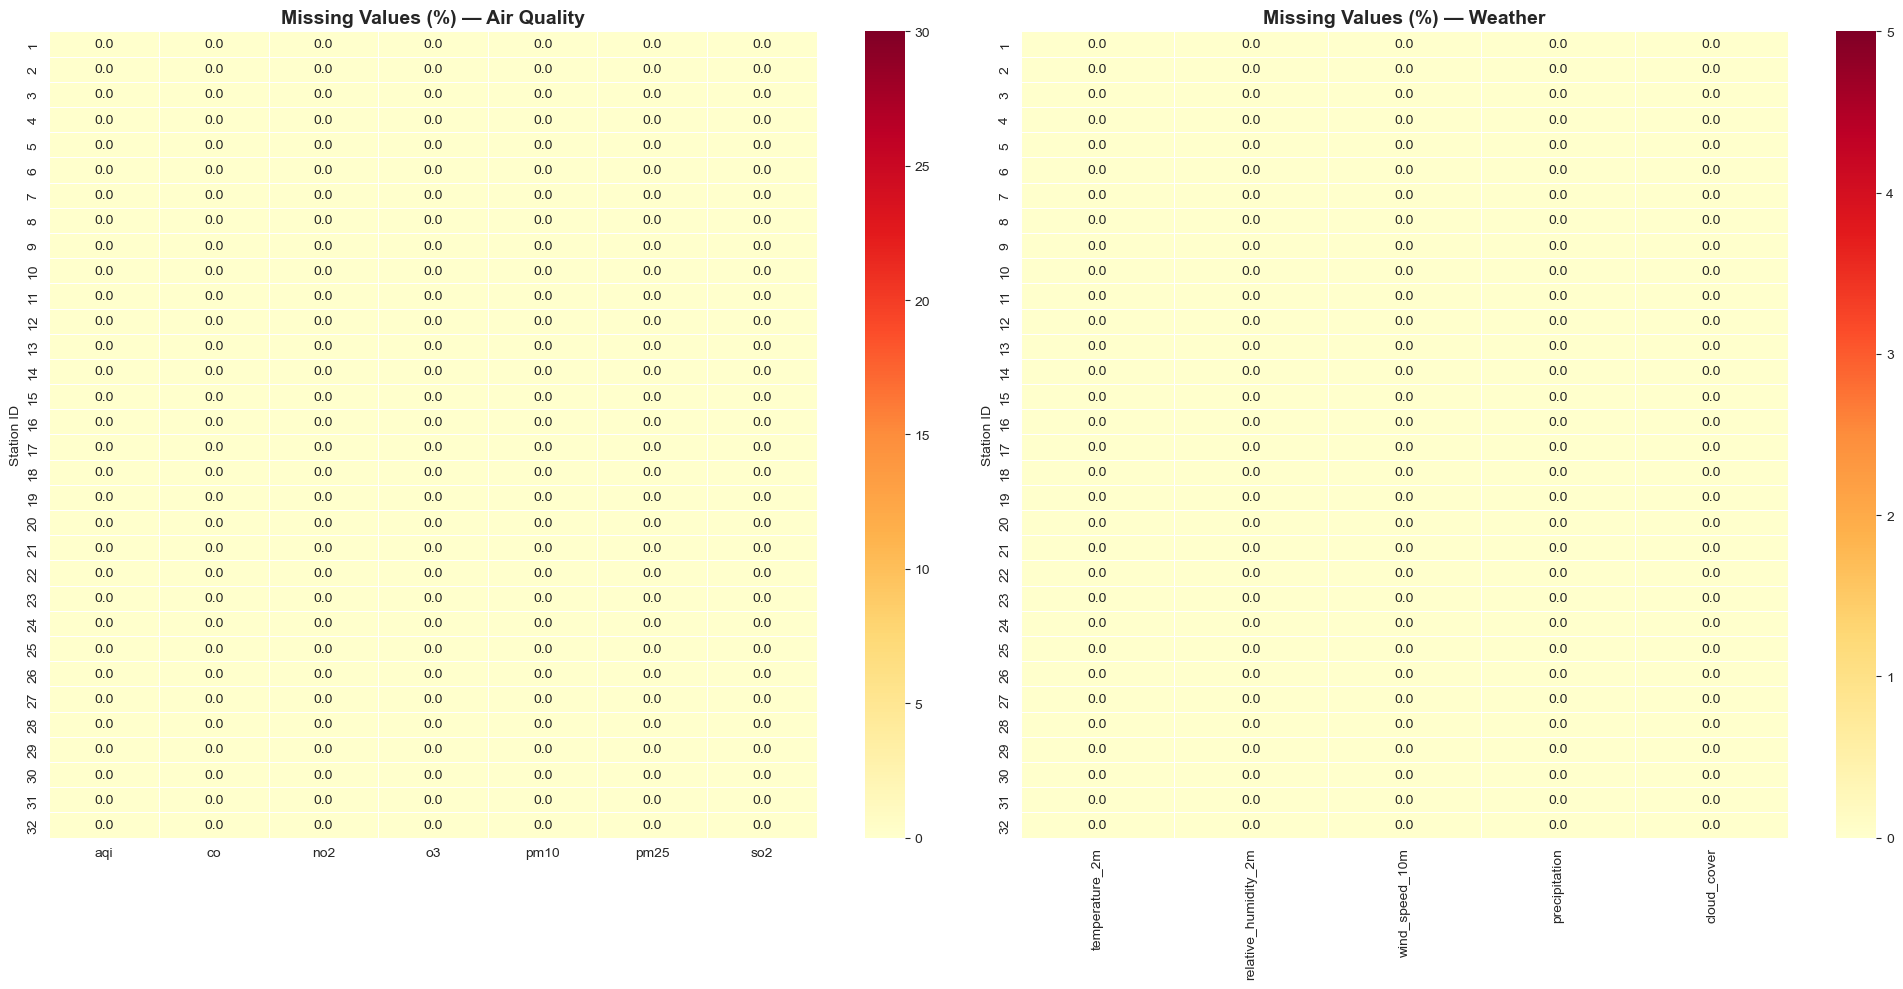


=== BẢNG TỔNG HỢP MISSING DATA ===


,Station,Province,District,Total Air Rows,Avg Air Missing (%),Avg Weather Missing (%)
0,1,Ha Noi,Cau Giay,25597,0.000000,0.000000
1,2,Ha Noi,Thanh Xuan,25597,0.000000,0.000000
2,3,Ha Noi,Tay Ho,25597,0.000000,0.000000
3,4,Ha Noi,Yen Lang,25597,0.000000,0.000000
4,5,Ha Noi,Gia Lam,25597,0.000000,0.000000
5,6,Ha Noi,Ba Vi,25597,0.000000,0.000000
6,7,TP.HCM,Quan 1,25597,0.000000,0.000000
7,8,TP.HCM,Quan 3,25597,0.000000,0.000000
8,9,TP.HCM,Quan Binh Thanh,25597,0.000000,0.000000
9,10,TP.HCM,Quan 10,25597,0.000000,0.000000


In [4]:
# === MISSING VALUE HEATMAP ===

# Air quality missing
missing_air = pd.DataFrame(index=range(1,33), columns=AIR_FEATURES, dtype=float)
total_rows_air = {}
for sid in range(1,33):
    if sid in all_air:
        df = all_air[sid]
        total_rows_air[sid] = len(df)
        for feat in AIR_FEATURES:
            if feat in df.columns:
                missing_air.loc[sid, feat] = df[feat].isna().mean() * 100

# Weather missing
w_cols_all = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation', 'cloud_cover']
missing_weather = pd.DataFrame(index=range(1,33), columns=w_cols_all, dtype=float)
for sid in range(1,33):
    if sid in all_weather:
        df = all_weather[sid]
        for feat in w_cols_all:
            if feat in df.columns:
                missing_weather.loc[sid, feat] = df[feat].isna().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Air heatmap
sns.heatmap(missing_air.astype(float), annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], vmin=0, vmax=30, linewidths=0.5)
axes[0].set_title('Missing Values (%) — Air Quality', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Station ID')

# Weather heatmap
sns.heatmap(missing_weather.astype(float), annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], vmin=0, vmax=5, linewidths=0.5)
axes[1].set_title('Missing Values (%) — Weather', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Station ID')

plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    'Station': range(1,33),
    'Province': [info.loc[info['station']==s, 'province'].values[0] if s in info['station'].values else '?' for s in range(1,33)],
    'District': [info.loc[info['station']==s, 'district'].values[0] if s in info['station'].values else '?' for s in range(1,33)],
    'Total Air Rows': [total_rows_air.get(s, 0) for s in range(1,33)],
    'Avg Air Missing (%)': [missing_air.loc[s].astype(float).mean() for s in range(1,33)],
    'Avg Weather Missing (%)': [missing_weather.loc[s].astype(float).mean() for s in range(1,33)],
})
print("\n=== BẢNG TỔNG HỢP MISSING DATA ===")
display(summary.style.background_gradient(subset=['Avg Air Missing (%)', 'Avg Weather Missing (%)'], cmap='YlOrRd'))


## 2. 📅 Phạm Vi Thời Gian & Mật Độ Dữ Liệu (Data Coverage)
Biểu đồ Gantt dưới đây cho thấy **khoảng thời gian** mà mỗi trạm có dữ liệu, giúp phát hiện trạm nào bị gián đoạn lâu.


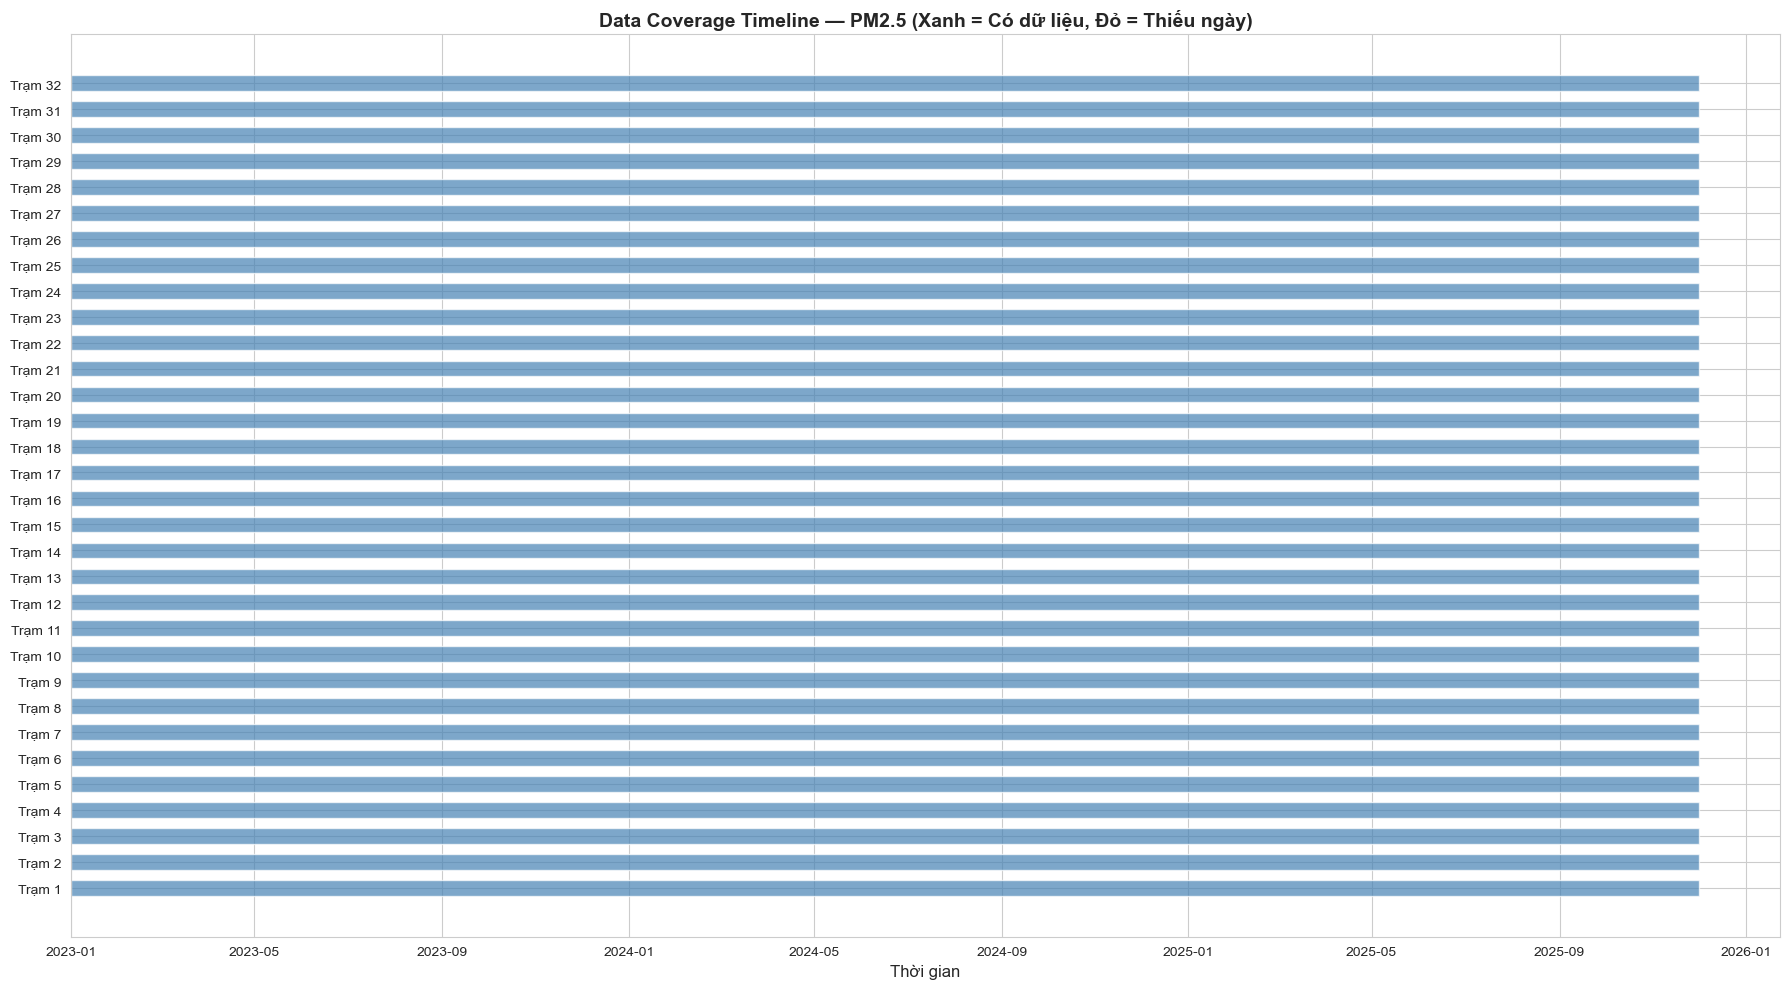

In [5]:
# === DATA COVERAGE TIMELINE ===
fig, ax = plt.subplots(figsize=(18, 10))

for i, sid in enumerate(range(1, 33)):
    if sid in all_air:
        df = all_air[sid]
        # Resample to daily and count non-null pm25
        daily = df['pm25'].resample('D').count()
        has_data = daily[daily > 0]
        if len(has_data) > 0:
            ax.barh(i, width=[(has_data.index[-1] - has_data.index[0]).days],
                    left=[has_data.index[0]], height=0.6, color='steelblue', alpha=0.7)
            # Mark gaps > 3 days
            gaps = daily[daily == 0]
            for gap_date in gaps.index:
                ax.barh(i, width=[1], left=[gap_date], height=0.6, color='red', alpha=0.3)

ax.set_yticks(range(32))
ax.set_yticklabels([f"Trạm {s}" for s in range(1,33)])
ax.set_xlabel('Thời gian', fontsize=12)
ax.set_title('Data Coverage Timeline — PM2.5 (Xanh = Có dữ liệu, Đỏ = Thiếu ngày)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. 🔧 Phát Hiện Lỗi Cảm Biến (Sensor Errors)
### 3a. Frozen Data (Dữ liệu đóng băng)
Cảm biến bị kẹt sẽ trả về **cùng một giá trị liên tục** trong nhiều giờ. Ta đếm số lần một feature lặp lại giá trị >= 12 giờ liên tiếp.

### 3b. OPC Sensor Error (Lỗi cảm biến quang)
PM2.5 và PM10 cùng tăng đột biến phi lý (PM2.5 > PM10 hoặc cả hai > 500) có thể là lỗi phần cứng cảm biến quang học.


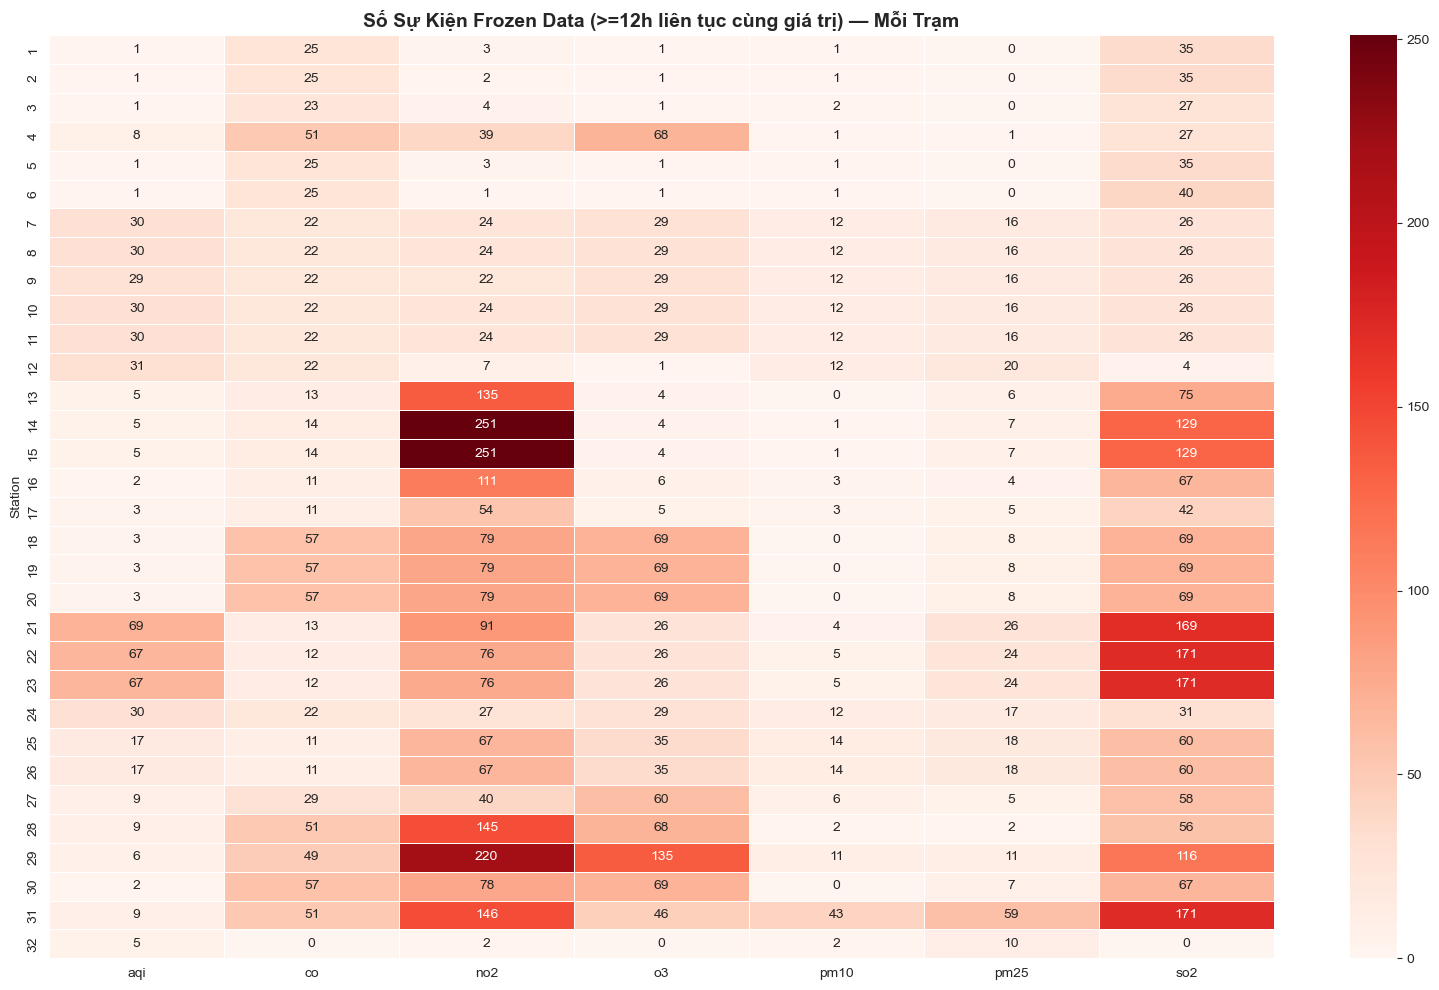


⚠️ Trạm có FROZEN nhiều nhất (PM2.5):
  Trạm 31 (Tra Vinh - Tra Vinh): 59 sự kiện frozen
  Trạm 21 (Khanh Hoa - Cam Ranh): 26 sự kiện frozen
  Trạm 22 (Khanh Hoa - Nha Trang): 24 sự kiện frozen
  Trạm 23 (Khanh Hoa - Dien Khanh): 24 sự kiện frozen
  Trạm 12 (TP.HCM - Huyen Binh Chanh): 20 sự kiện frozen
  Trạm 25 (Dong Nai - Long Thanh): 18 sự kiện frozen
  Trạm 26 (Dong Nai - Nhon Trach): 18 sự kiện frozen
  Trạm 24 (Dong Nai - Bien Hoa): 17 sự kiện frozen
  Trạm 11 (TP.HCM - Quan 11): 16 sự kiện frozen
  Trạm 7 (TP.HCM - Quan 1): 16 sự kiện frozen


In [6]:
# === FROZEN DATA DETECTION (consecutive same values >= 12h) ===

def count_frozen_events(series, min_hours=12):
    """Đếm số sự kiện frozen data (giá trị lặp lại >= min_hours giờ liên tiếp)"""
    if series.isna().all():
        return 0
    same = (series == series.shift()).astype(int)
    groups = same.ne(same.shift()).cumsum()
    frozen_counts = same.groupby(groups).sum()
    return (frozen_counts >= min_hours).sum()

# Chạy cho tất cả trạm
frozen_results = []
for sid in range(1, 33):
    if sid in all_air:
        row = {'Station': sid}
        for feat in AIR_FEATURES:
            if feat in all_air[sid].columns:
                row[feat] = count_frozen_events(all_air[sid][feat])
        frozen_results.append(row)

frozen_df = pd.DataFrame(frozen_results).set_index('Station')

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(frozen_df.astype(float), annot=True, fmt='.0f', cmap='Reds',
            linewidths=0.5, ax=ax)
ax.set_title('Số Sự Kiện Frozen Data (>=12h liên tục cùng giá trị) — Mỗi Trạm', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️ Trạm có FROZEN nhiều nhất (PM2.5):")
top_frozen = frozen_df['pm25'].sort_values(ascending=False).head(10)
for sid, count in top_frozen.items():
    prov = info.loc[info['station']==sid, 'province'].values[0] if sid in info['station'].values else '?'
    dist = info.loc[info['station']==sid, 'district'].values[0] if sid in info['station'].values else '?'
    print(f"  Trạm {sid} ({prov} - {dist}): {int(count)} sự kiện frozen")


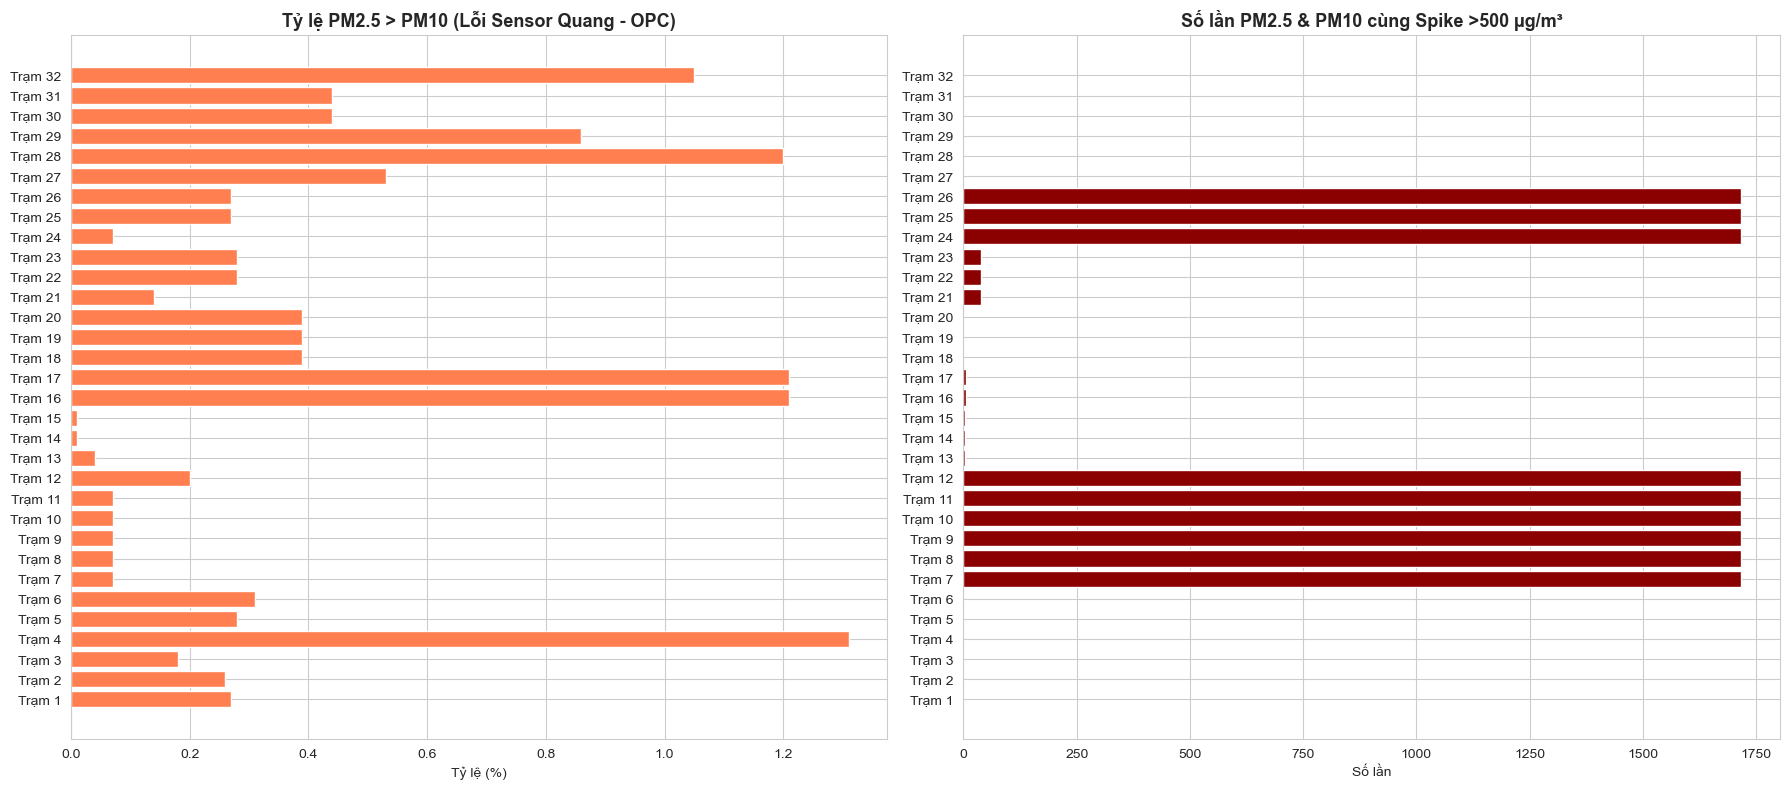

,PM2.5 > PM10 (bất hợp lý),PM2.5 > PM10 (%),Dual Spike >500,Total Rows
Station,,,,
1,69,0.270000,0,25597
2,67,0.260000,0,25597
3,47,0.180000,0,25597
4,336,1.310000,0,25597
5,71,0.280000,0,25597
6,80,0.310000,0,25597
7,18,0.070000,1717,25597
8,18,0.070000,1717,25597
9,18,0.070000,1717,25597


In [7]:
# === OPC SENSOR ERROR DETECTION ===
# PM2.5 > PM10 (vật lý bất hợp lý) hoặc cả hai cùng spike > 500

opc_errors = []
for sid in range(1, 33):
    if sid in all_air:
        df = all_air[sid]
        if 'pm25' in df.columns and 'pm10' in df.columns:
            # PM2.5 > PM10 (không hợp lý vì PM2.5 là tập con của PM10)  
            physically_wrong = (df['pm25'] > df['pm10']).sum()
            # Cả hai cùng spike >500
            dual_spike = ((df['pm25'] > 500) & (df['pm10'] > 500)).sum()
            total = len(df)
            opc_errors.append({
                'Station': sid,
                'PM2.5 > PM10 (bất hợp lý)': physically_wrong,
                'PM2.5 > PM10 (%)': round(physically_wrong / total * 100, 2) if total > 0 else 0,
                'Dual Spike >500': dual_spike,
                'Total Rows': total
            })

opc_df = pd.DataFrame(opc_errors).set_index('Station')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart PM2.5 > PM10
axes[0].barh(range(len(opc_df)), opc_df['PM2.5 > PM10 (%)'], color='coral')
axes[0].set_yticks(range(len(opc_df)))
axes[0].set_yticklabels([f"Trạm {s}" for s in opc_df.index])
axes[0].set_xlabel('Tỷ lệ (%)')
axes[0].set_title('Tỷ lệ PM2.5 > PM10 (Lỗi Sensor Quang - OPC)', fontsize=13, fontweight='bold')

# Bar chart Dual Spike
axes[1].barh(range(len(opc_df)), opc_df['Dual Spike >500'], color='darkred')
axes[1].set_yticks(range(len(opc_df)))
axes[1].set_yticklabels([f"Trạm {s}" for s in opc_df.index])
axes[1].set_xlabel('Số lần')
axes[1].set_title('Số lần PM2.5 & PM10 cùng Spike >500 µg/m³', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

display(opc_df.style.background_gradient(subset=['PM2.5 > PM10 (%)'], cmap='Reds'))


## 4. 🌫️ Phân Tích Ô Nhiễm Cực Đoan (Extreme PM2.5 Events)
Đánh giá mức ô nhiễm PM2.5 theo **ngưỡng AQI Việt Nam**:
- 🟢 Tốt: PM2.5 < 25
- 🟡 Trung bình: 25 ≤ PM2.5 < 50
- 🟠 Kém: 50 ≤ PM2.5 < 100
- 🔴 Xấu: 100 ≤ PM2.5 < 200
- 🟣 Nguy hiểm: PM2.5 ≥ 200


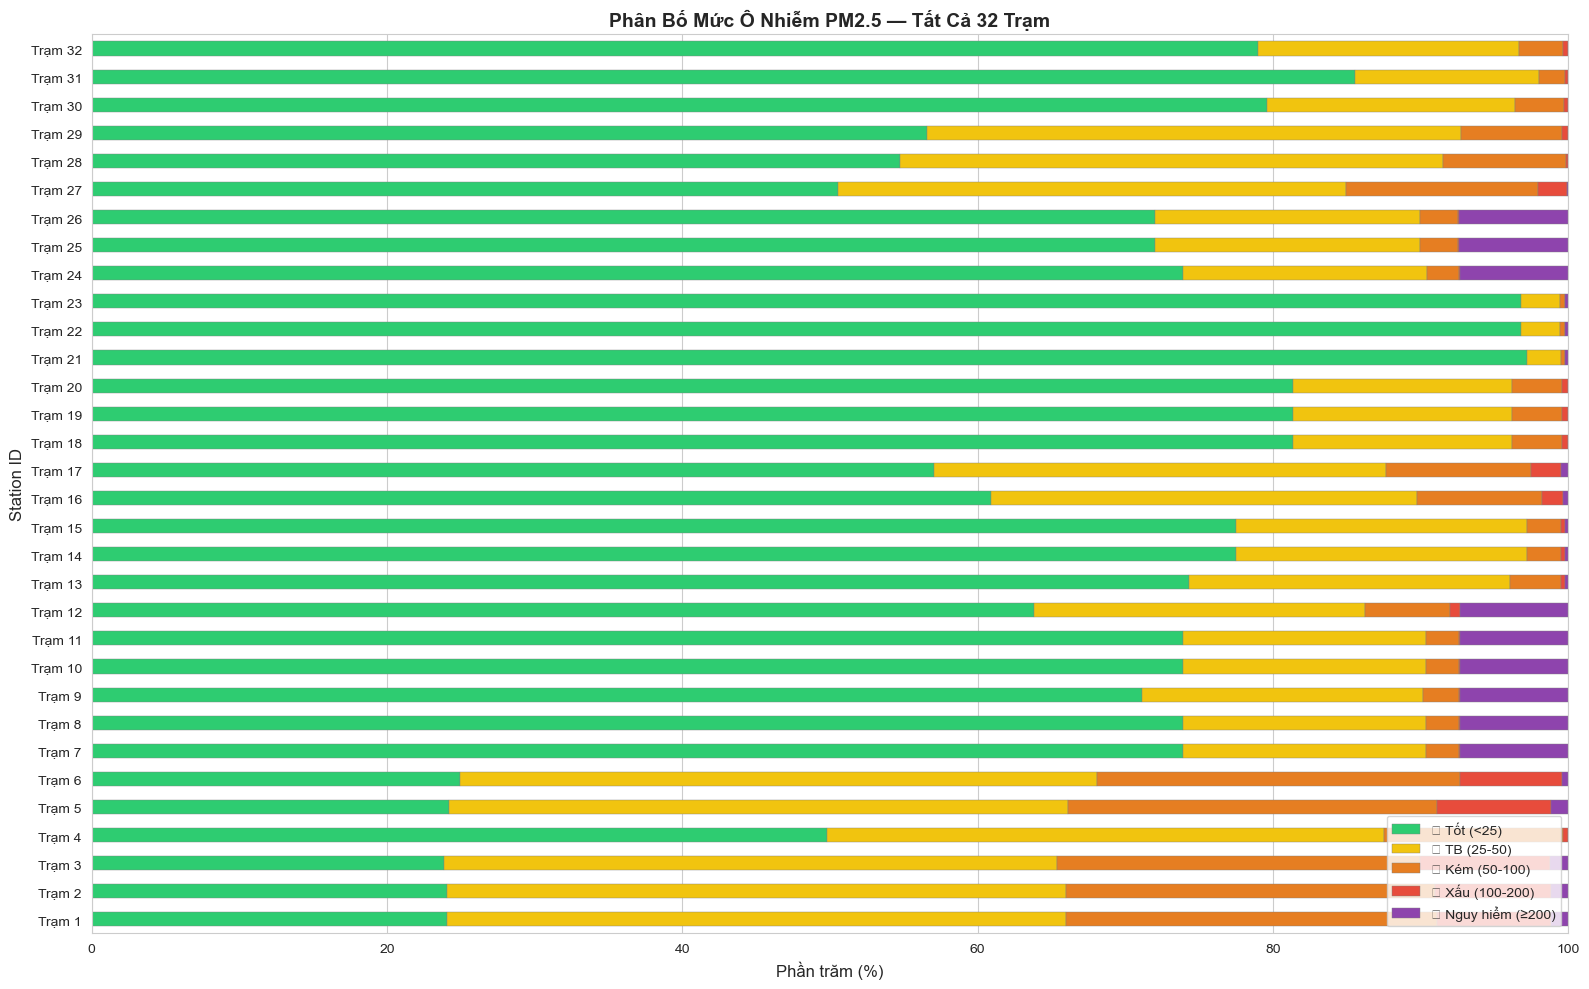


=== THỐNG KÊ Ô NHIỄM CỰC ĐOAN ===


,Mean PM2.5,Max PM2.5,Std PM2.5,🔴 Xấu (100-200),🟣 Nguy hiểm (≥200)
Station,,,,,
1,49.7,457.0,40.1,7.7,1.2
2,49.7,457.0,40.2,7.8,1.2
3,51.0,457.0,41.8,8.8,1.3
4,28.5,141.0,18.6,0.3,0.0
5,49.6,457.0,40.2,7.7,1.2
6,46.6,457.0,34.0,6.9,0.4
7,83.4,985.0,243.2,0.1,7.3
8,83.4,985.0,243.2,0.1,7.3
9,84.2,985.0,243.0,0.1,7.3


In [8]:
# === EXTREME POLLUTION DISTRIBUTION ===

pollution_levels = []
for sid in range(1, 33):
    if sid in all_air and 'pm25' in all_air[sid].columns:
        pm = all_air[sid]['pm25'].dropna()
        total = len(pm)
        if total == 0:
            continue
        pollution_levels.append({
            'Station': sid,
            '🟢 Tốt (<25)': (pm < 25).sum() / total * 100,
            '🟡 TB (25-50)': ((pm >= 25) & (pm < 50)).sum() / total * 100,
            '🟠 Kém (50-100)': ((pm >= 50) & (pm < 100)).sum() / total * 100,
            '🔴 Xấu (100-200)': ((pm >= 100) & (pm < 200)).sum() / total * 100,
            '🟣 Nguy hiểm (≥200)': (pm >= 200).sum() / total * 100,
            'Mean PM2.5': pm.mean(),
            'Max PM2.5': pm.max(),
            'Std PM2.5': pm.std()
        })

poll_df = pd.DataFrame(pollution_levels).set_index('Station')

# Stacked bar chart
level_cols = ['🟢 Tốt (<25)', '🟡 TB (25-50)', '🟠 Kém (50-100)', '🔴 Xấu (100-200)', '🟣 Nguy hiểm (≥200)']
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']

fig, ax = plt.subplots(figsize=(16, 10))
poll_df[level_cols].plot(kind='barh', stacked=True, color=colors, ax=ax, edgecolor='gray', linewidth=0.3)
ax.set_xlabel('Phần trăm (%)', fontsize=12)
ax.set_ylabel('Station ID', fontsize=12)
ax.set_title('Phân Bố Mức Ô Nhiễm PM2.5 — Tất Cả 32 Trạm', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_yticklabels([f"Trạm {int(s)}" for s in poll_df.index])
plt.tight_layout()
plt.show()

# Statistics table
print("\n=== THỐNG KÊ Ô NHIỄM CỰC ĐOAN ===")
display(poll_df[['Mean PM2.5', 'Max PM2.5', 'Std PM2.5', '🔴 Xấu (100-200)', '🟣 Nguy hiểm (≥200)']].style.format('{:.1f}').background_gradient(cmap='YlOrRd'))


## 5. 🌦️ So Sánh Thời Tiết Theo Mùa — Tất Cả 32 Trạm
Chia năm thành 4 mùa: Xuân (T3-T5), Hạ (T6-T8), Thu (T9-T11), Đông (T12-T2). So sánh nhiệt độ, lượng mưa, tốc độ gió theo mùa giữa các trạm để thấy sự khác biệt khí hậu vùng miền.


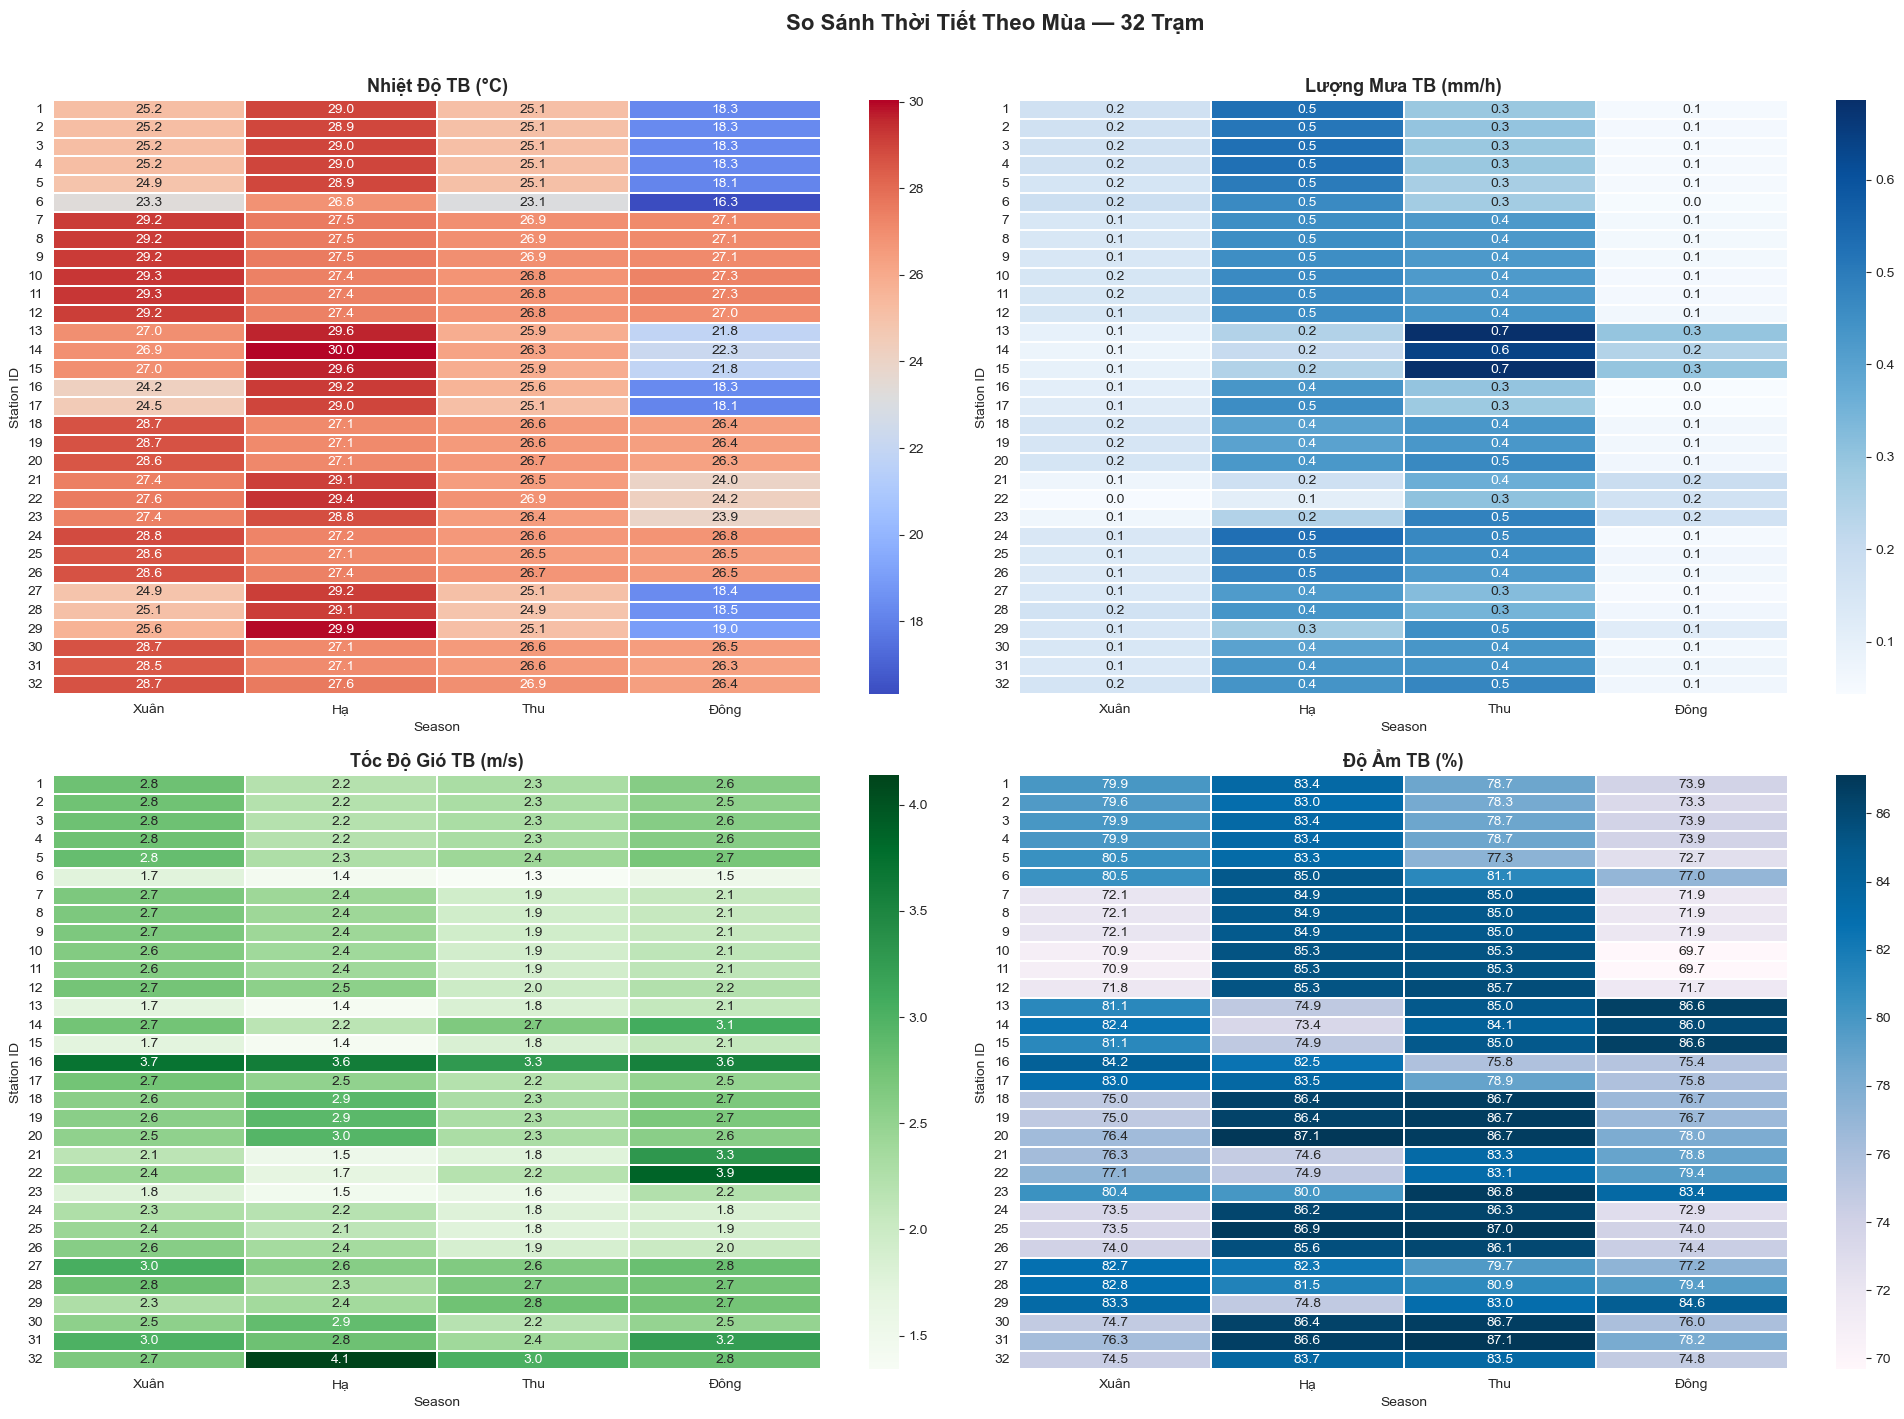

In [9]:
# === SEASONAL WEATHER ANALYSIS ===

def get_season(month):
    if month in [3, 4, 5]: return 'Xuân'
    if month in [6, 7, 8]: return 'Hạ'
    if month in [9, 10, 11]: return 'Thu'
    return 'Đông'

seasonal_data = []
for sid in range(1, 33):
    if sid in all_weather:
        df = all_weather[sid].copy()
        df['season'] = df.index.month.map(get_season)
        df['month'] = df.index.month
        for season in ['Xuân', 'Hạ', 'Thu', 'Đông']:
            subset = df[df['season'] == season]
            row = {'Station': sid, 'Season': season}
            if 'temperature_2m' in subset.columns:
                row['Temp (°C)'] = subset['temperature_2m'].mean()
            if 'precipitation' in subset.columns:
                row['Rain (mm/h)'] = subset['precipitation'].mean()
            if 'wind_speed_10m' in subset.columns:
                row['Wind (m/s)'] = subset['wind_speed_10m'].mean()
            if 'relative_humidity_2m' in subset.columns:
                row['Humidity (%)'] = subset['relative_humidity_2m'].mean()
            seasonal_data.append(row)

seasonal_df = pd.DataFrame(seasonal_data)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
metrics = [('Temp (°C)', 'Nhiệt Độ TB (°C)', 'coolwarm'),
           ('Rain (mm/h)', 'Lượng Mưa TB (mm/h)', 'Blues'),
           ('Wind (m/s)', 'Tốc Độ Gió TB (m/s)', 'Greens'),
           ('Humidity (%)', 'Độ Ẩm TB (%)', 'PuBu')]

for ax, (col, title, cmap) in zip(axes.flat, metrics):
    pivot = seasonal_df.pivot(index='Station', columns='Season', values=col)
    pivot = pivot[['Xuân', 'Hạ', 'Thu', 'Đông']]
    sns.heatmap(pivot.astype(float), annot=True, fmt='.1f', cmap=cmap, ax=ax, linewidths=0.3)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Station ID')

plt.suptitle('So Sánh Thời Tiết Theo Mùa — 32 Trạm', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 6. 📈 Xu Hướng PM2.5 Theo Tháng — So Sánh Tất Cả Trạm
Biểu đồ chồng lấp (Overlay) cho thấy PM2.5 trung bình hàng tháng của mỗi trạm. Trạm nào có biên độ dao động lớn nhất → Thú vị nhất cho Model.


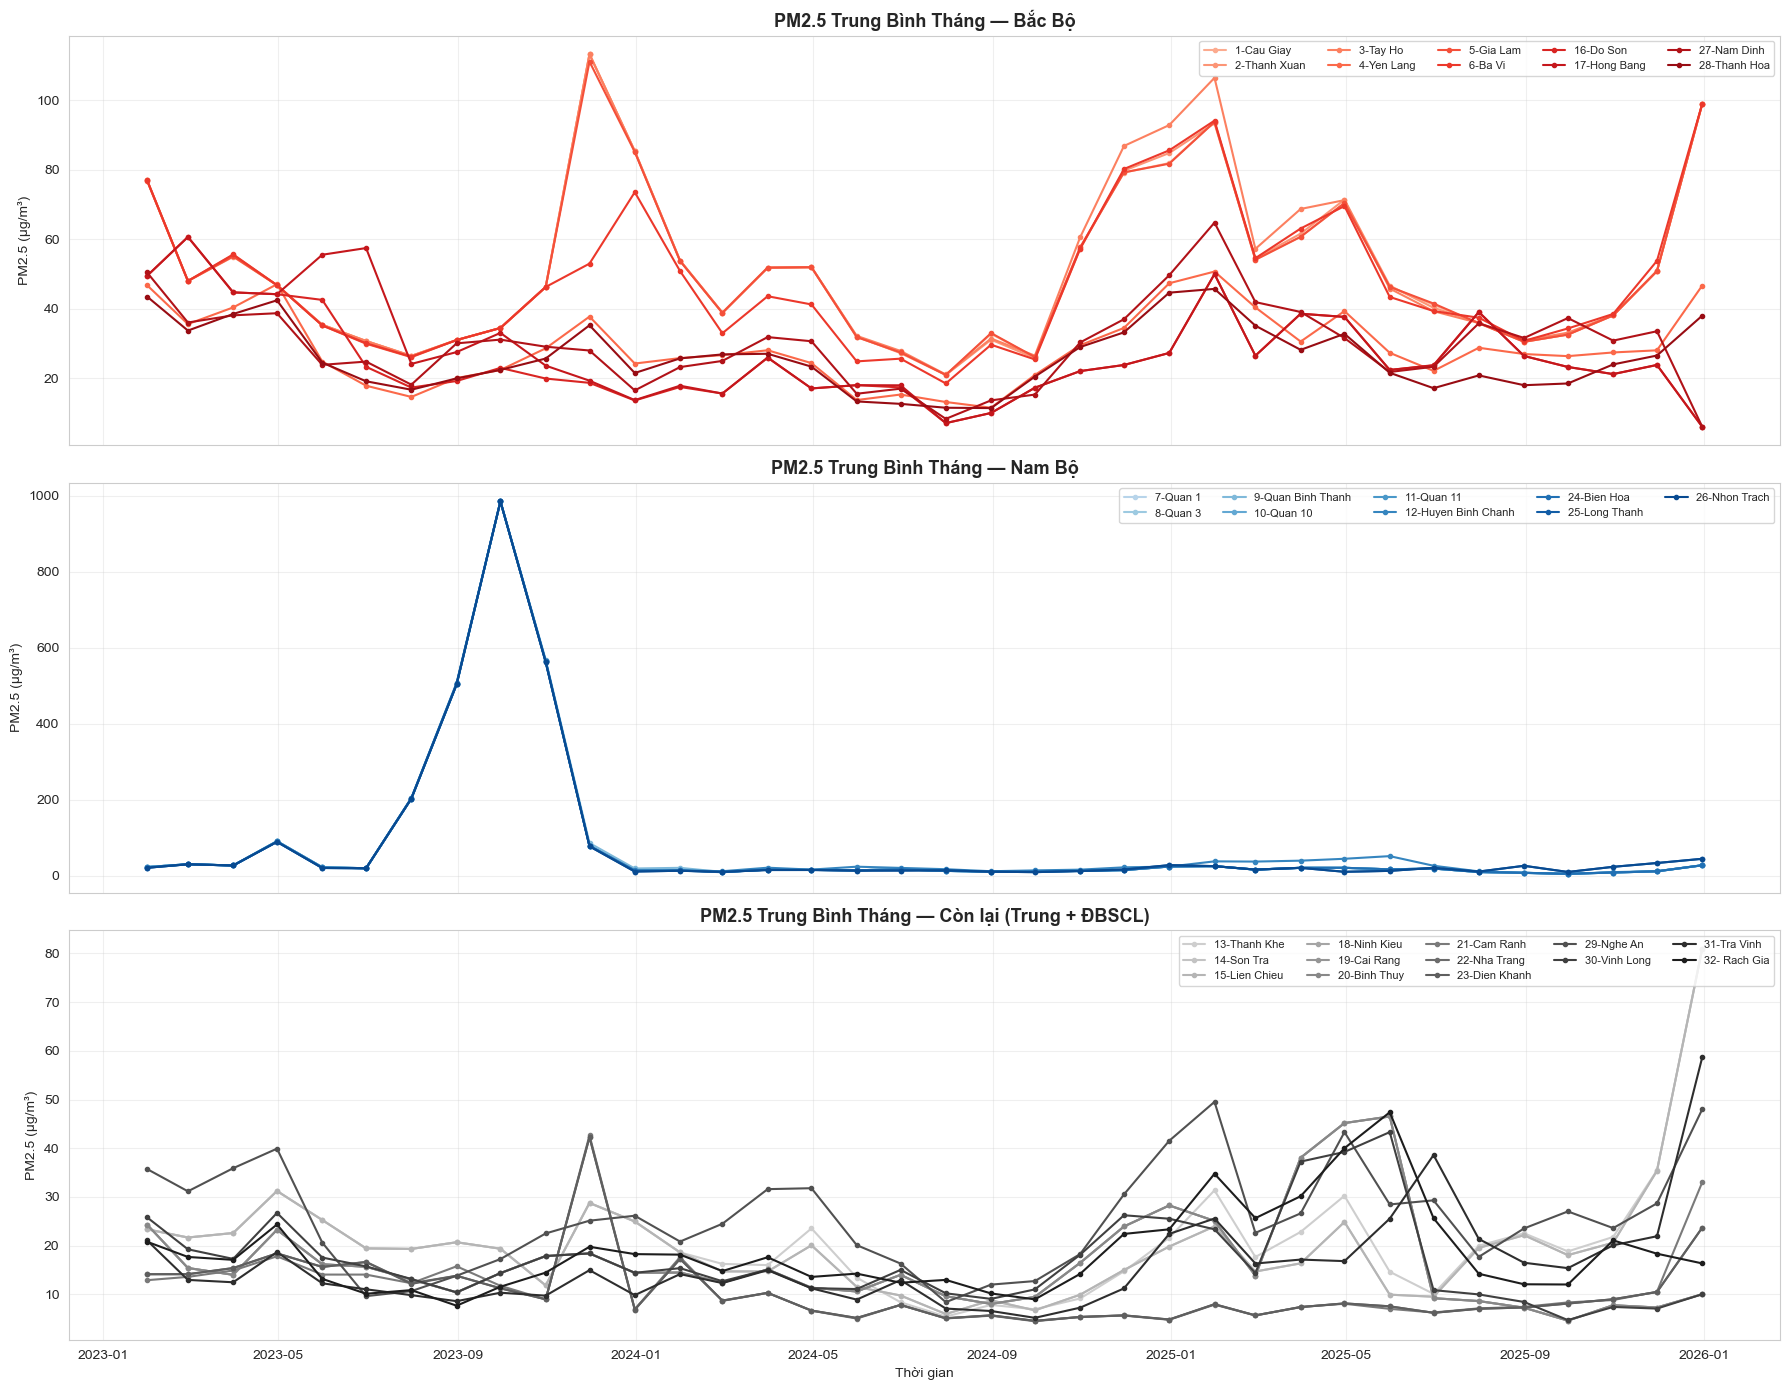

In [10]:
# === MONTHLY PM2.5 TREND OVERLAY ===

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

# Group by region
north_ids = [1, 2, 3, 4, 5, 6, 16, 17, 27, 28]
south_ids = [7, 8, 9, 10, 11, 12, 24, 25, 26]
other_ids = [13, 14, 15, 18, 19, 20, 21, 22, 23, 29, 30, 31, 32]

groups = [('Bắc Bộ', north_ids, 'Reds'), ('Nam Bộ', south_ids, 'Blues'), ('Còn lại (Trung + ĐBSCL)', other_ids, 'Greys')]

for ax, (label, ids, cmap_name) in zip(axes, groups):
    cmap = plt.get_cmap(cmap_name)
    for i, sid in enumerate(ids):
        if sid in all_air and 'pm25' in all_air[sid].columns:
            monthly = all_air[sid]['pm25'].resample('ME').mean().dropna()
            color = cmap(0.3 + 0.6 * i / max(len(ids)-1, 1))
            prov = info.loc[info['station']==sid, 'province'].values[0] if sid in info['station'].values else '?'
            dist = info.loc[info['station']==sid, 'district'].values[0] if sid in info['station'].values else '?'
            ax.plot(monthly.index, monthly.values, marker='o', markersize=3, label=f"{sid}-{dist}", color=color, linewidth=1.5)
    ax.set_title(f'PM2.5 Trung Bình Tháng — {label}', fontsize=13, fontweight='bold')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.legend(fontsize=8, ncol=5, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.xlabel('Thời gian')
plt.tight_layout()
plt.show()


## 7. 🔗 Ma Trận Tương Quan Feature — Từng Nhóm Trạm
Hiển thị Correlation Heatmap cho từng cụm trạm (Bắc, Nam, Khác) dựa trên tất cả features có sẵn.


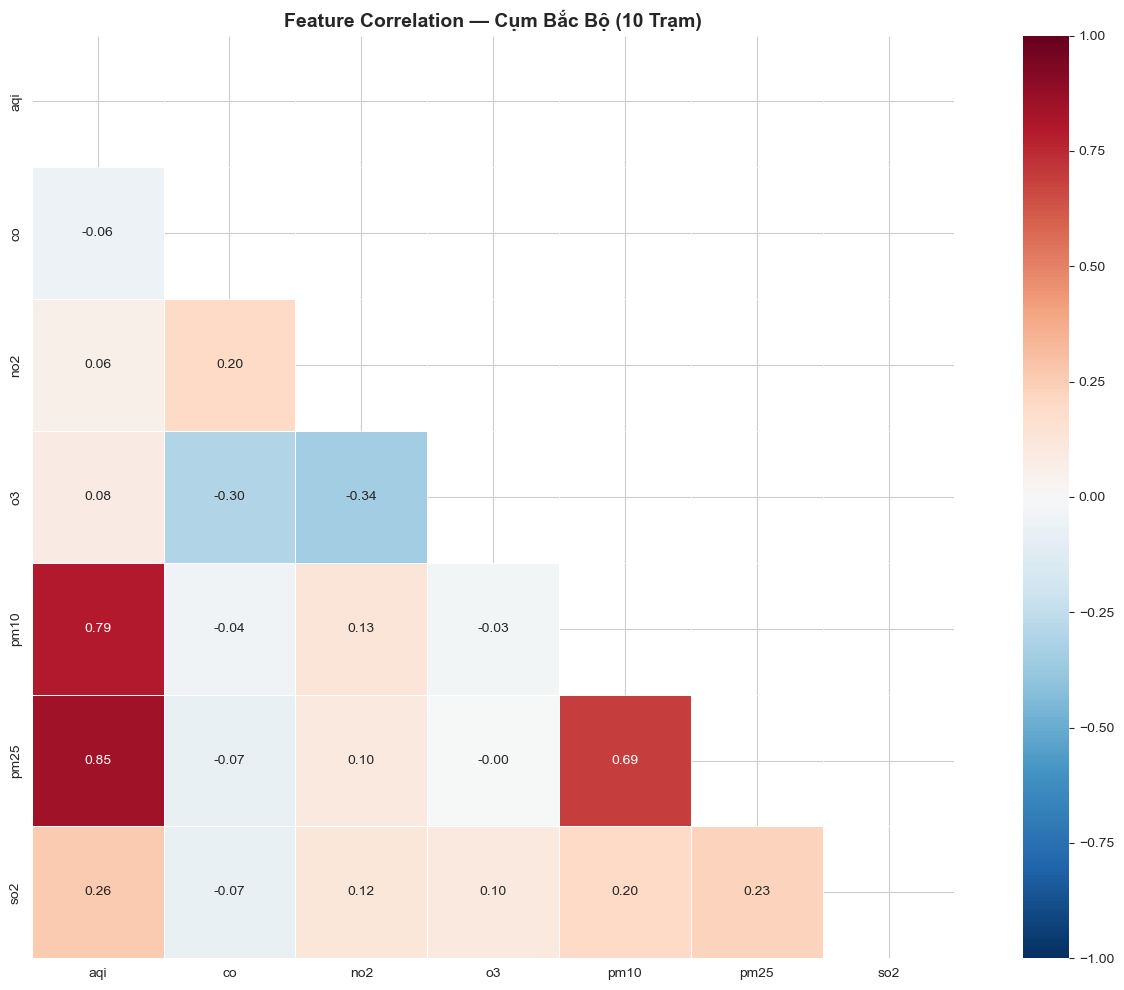

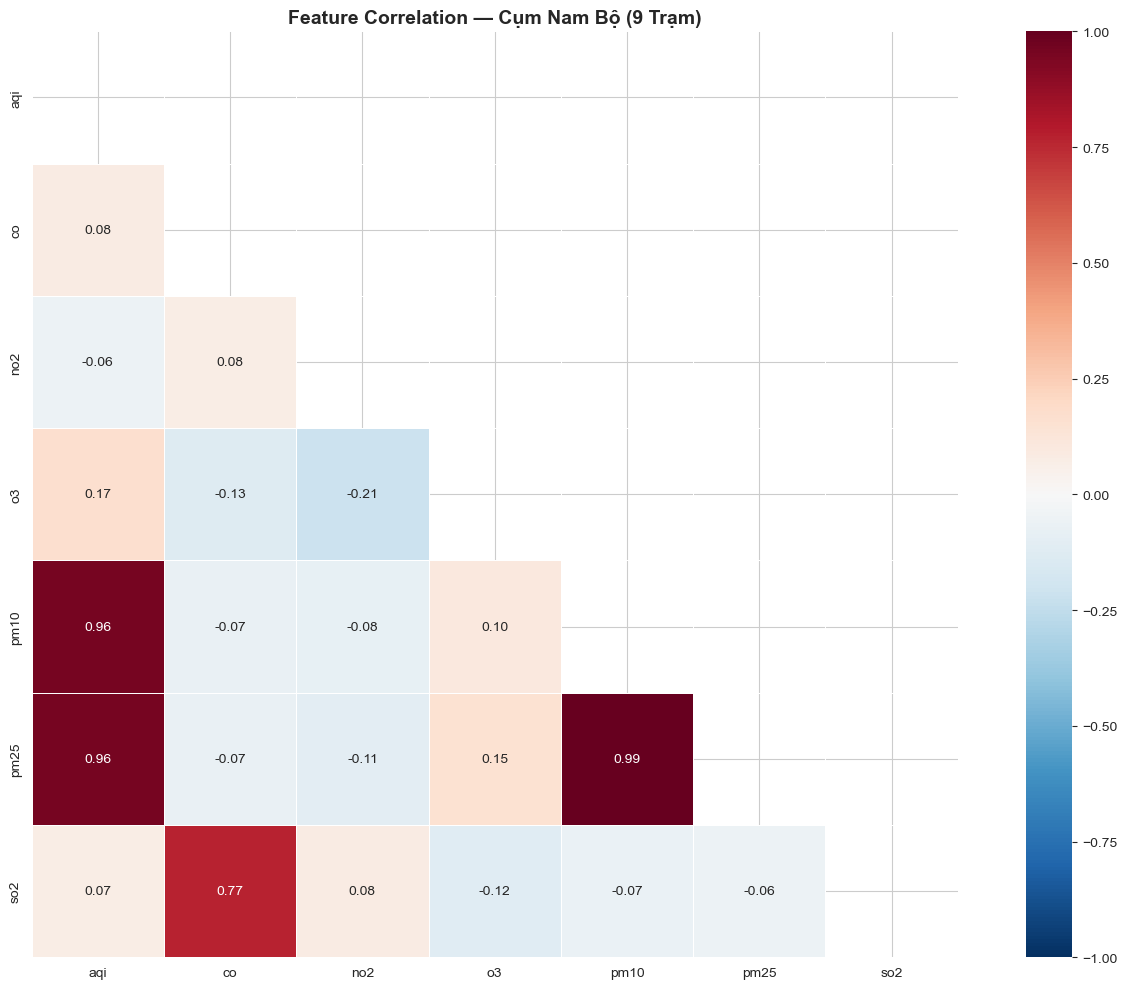

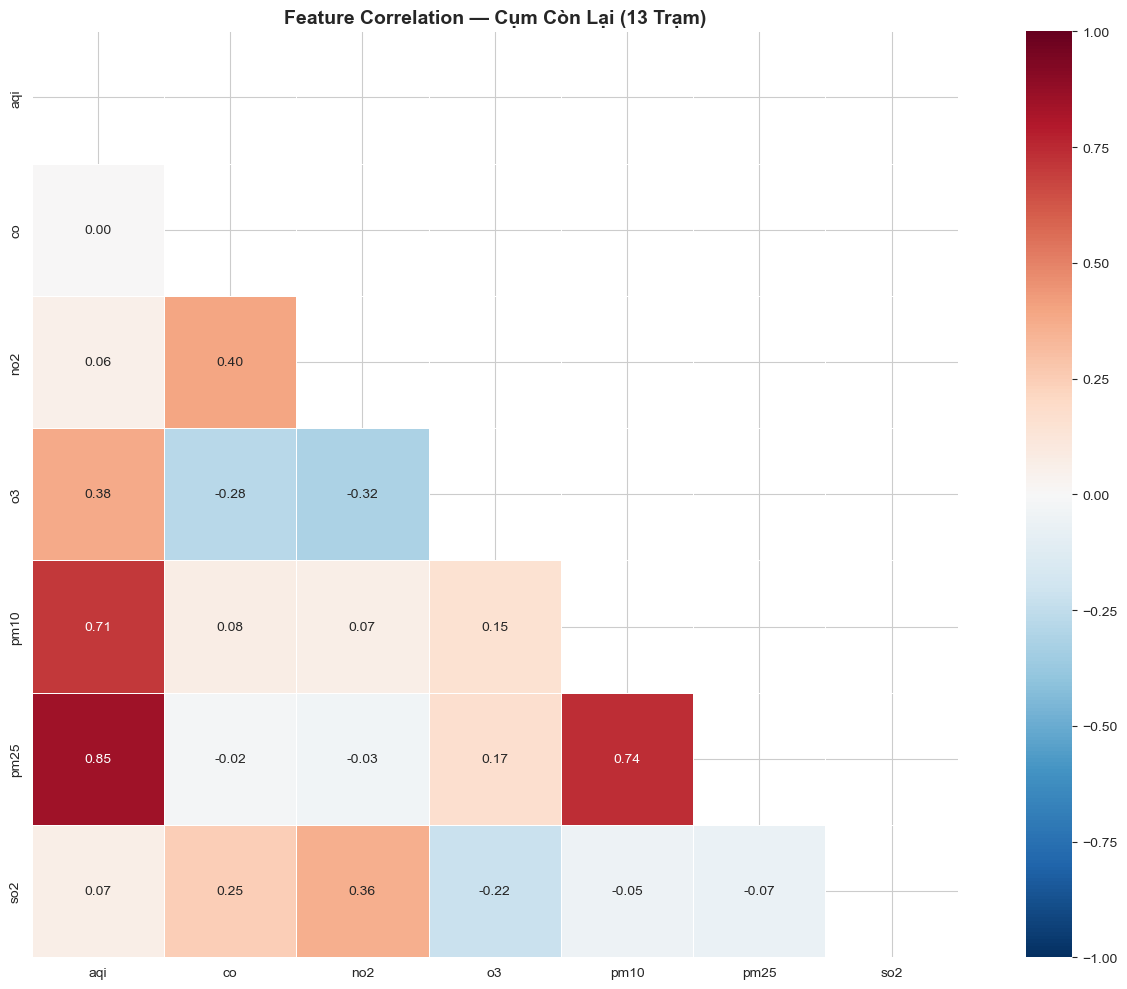

In [11]:
# === CORRELATION HEATMAP PER GROUP ===

def plot_correlation_group(station_ids, group_name, figsize=(14, 10)):
    """Gộp dữ liệu nhiều trạm rồi tính correlation chung"""
    frames = []
    for sid in station_ids:
        if sid in all_air:
            df = all_air[sid][AIR_FEATURES].copy()
            df.columns = [f"{c}" for c in df.columns]
            frames.append(df)
    if not frames:
        return
    combined = pd.concat(frames, axis=0)
    corr = combined.corr()
    
    fig, ax = plt.subplots(figsize=figsize)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, square=True)
    ax.set_title(f'Feature Correlation — {group_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_correlation_group([1,2,3,4,5,6,16,17,27,28], 'Cụm Bắc Bộ (10 Trạm)')
plot_correlation_group([7,8,9,10,11,12,24,25,26], 'Cụm Nam Bộ (9 Trạm)')
plot_correlation_group([13,14,15,18,19,20,21,22,23,29,30,31,32], 'Cụm Còn Lại (13 Trạm)')


## 8. 🔍 Correlation Chi Tiết Từng Trạm (Air + Weather kết hợp)
Phần này merge Air + Weather lại với nhau rồi vẽ Correlation cho **từng trạm riêng lẻ**. Bạn có thể thay đổi biến `STATIONS_TO_PLOT` để chọn trạm muốn xem.


InvalidIndexError: Reindexing only valid with uniquely valued Index objects

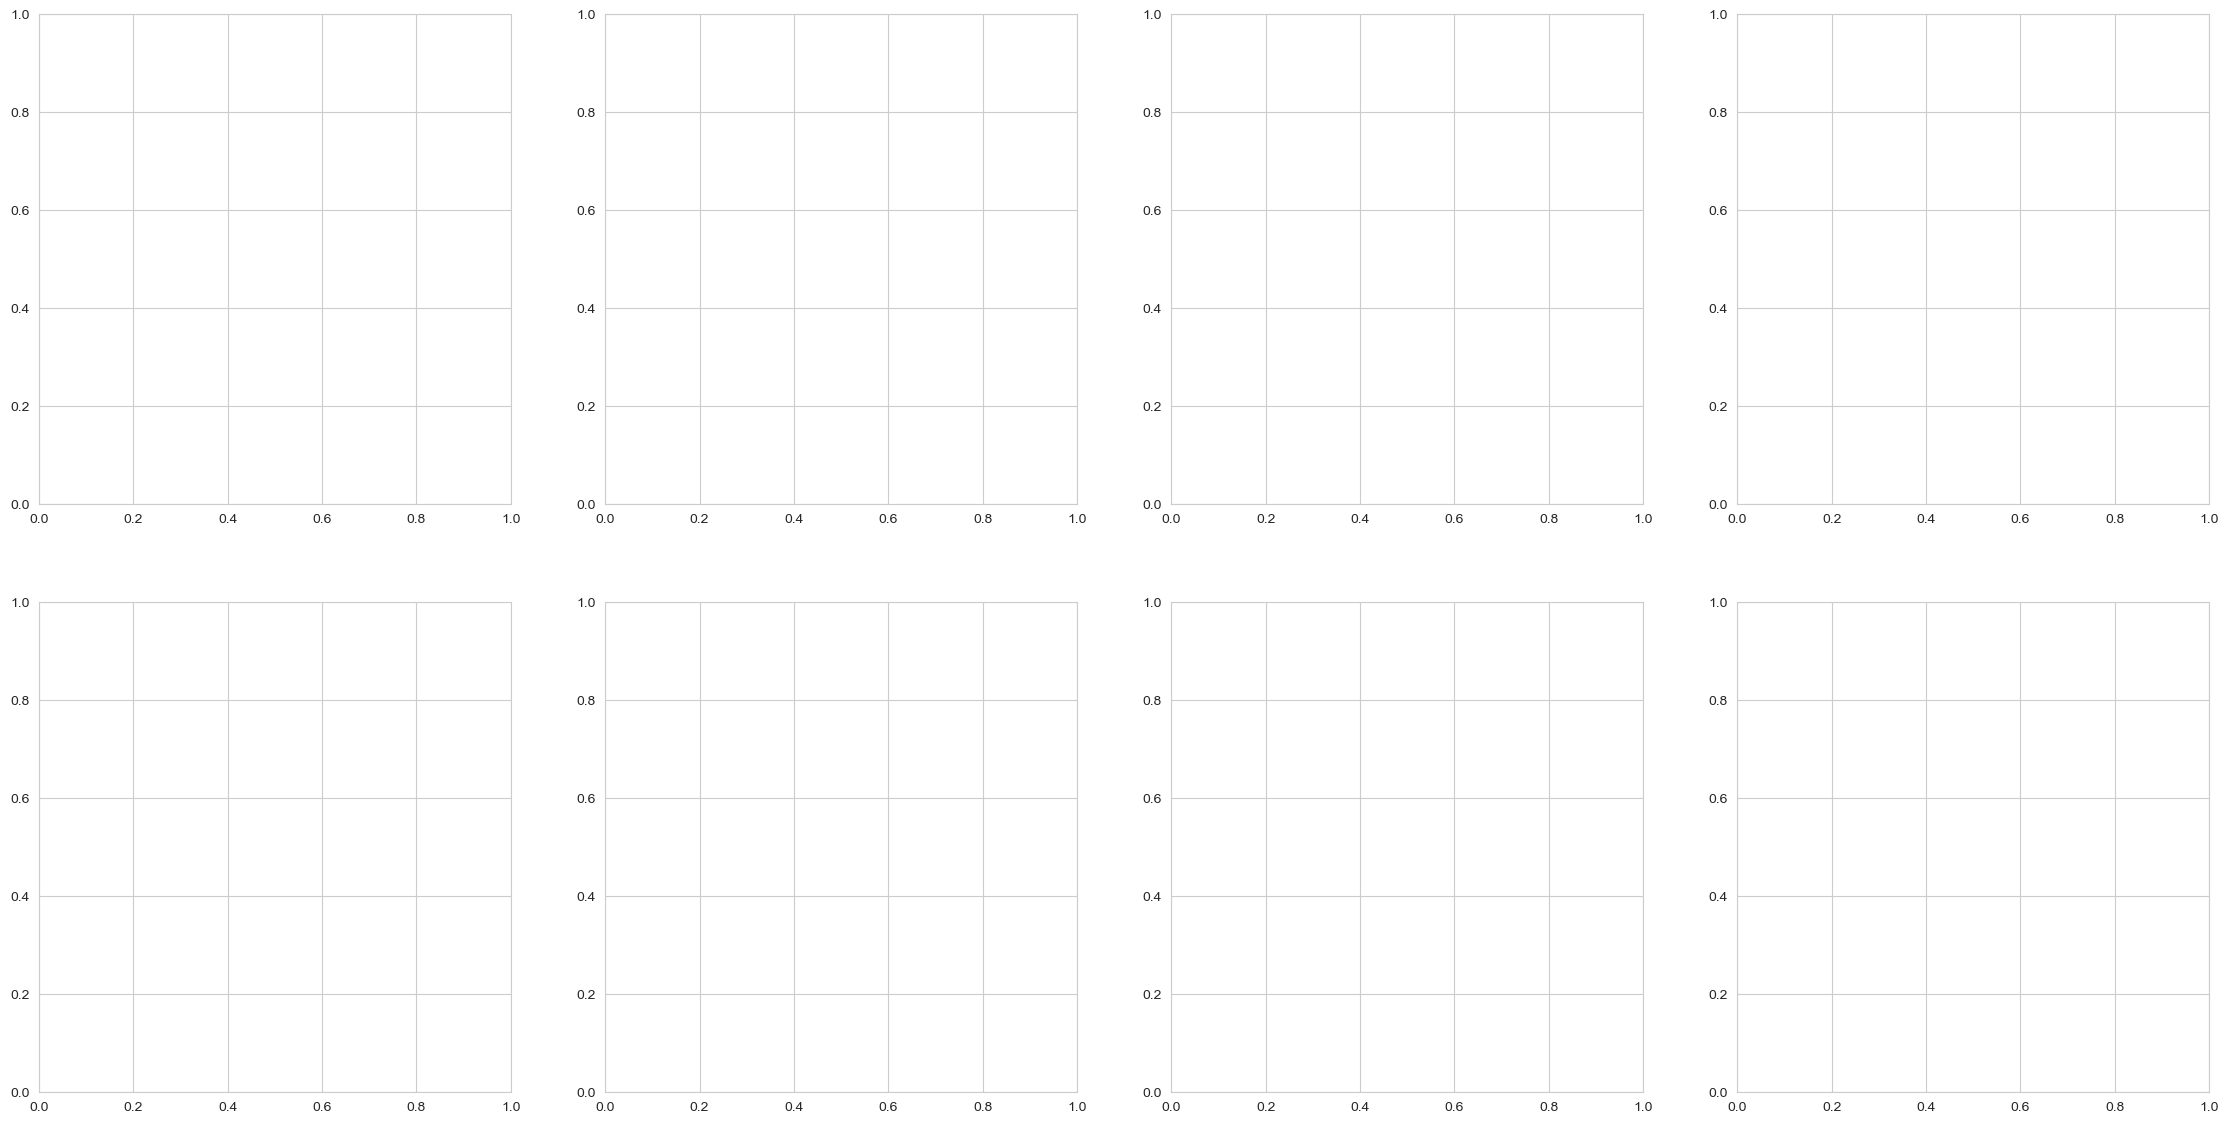

In [12]:
# === PER-STATION AIR+WEATHER CORRELATION ===
# Thay đổi list này để xem trạm bạn muốn
STATIONS_TO_PLOT = [1, 2, 7, 8, 13, 24, 28]

fig, axes = plt.subplots(2, 4, figsize=(28, 14))
axes = axes.flatten()

for i, sid in enumerate(STATIONS_TO_PLOT):
    if i >= len(axes):
        break
    ax = axes[i]
    
    frames = []
    if sid in all_air:
        frames.append(all_air[sid][AIR_FEATURES])
    if sid in all_weather:
        frames.append(all_weather[sid])
    
    if frames:
        merged = pd.concat(frames, axis=1, join='inner')
        corr = merged.corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, fmt='.1f', cmap='RdBu_r',
                    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3,
                    annot_kws={'size': 7}, cbar_kws={'shrink': 0.6})
        prov = info.loc[info['station']==sid, 'province'].values[0] if sid in info['station'].values else '?'
        dist = info.loc[info['station']==sid, 'district'].values[0] if sid in info['station'].values else '?'
        ax.set_title(f'Trạm {sid} - {dist} ({prov})', fontsize=10, fontweight='bold')

# Hide unused axes
for j in range(len(STATIONS_TO_PLOT), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Correlation Heatmap (Air + Weather) — Từng Trạm', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 9. 📦 Boxplot So Sánh Phân Phối Feature — Tất Cả 32 Trạm
Mỗi subplot là một feature, trục X là Station ID. Dễ dàng nhận ra trạm nào có outlier cực lớn hoặc phân phối lệch.


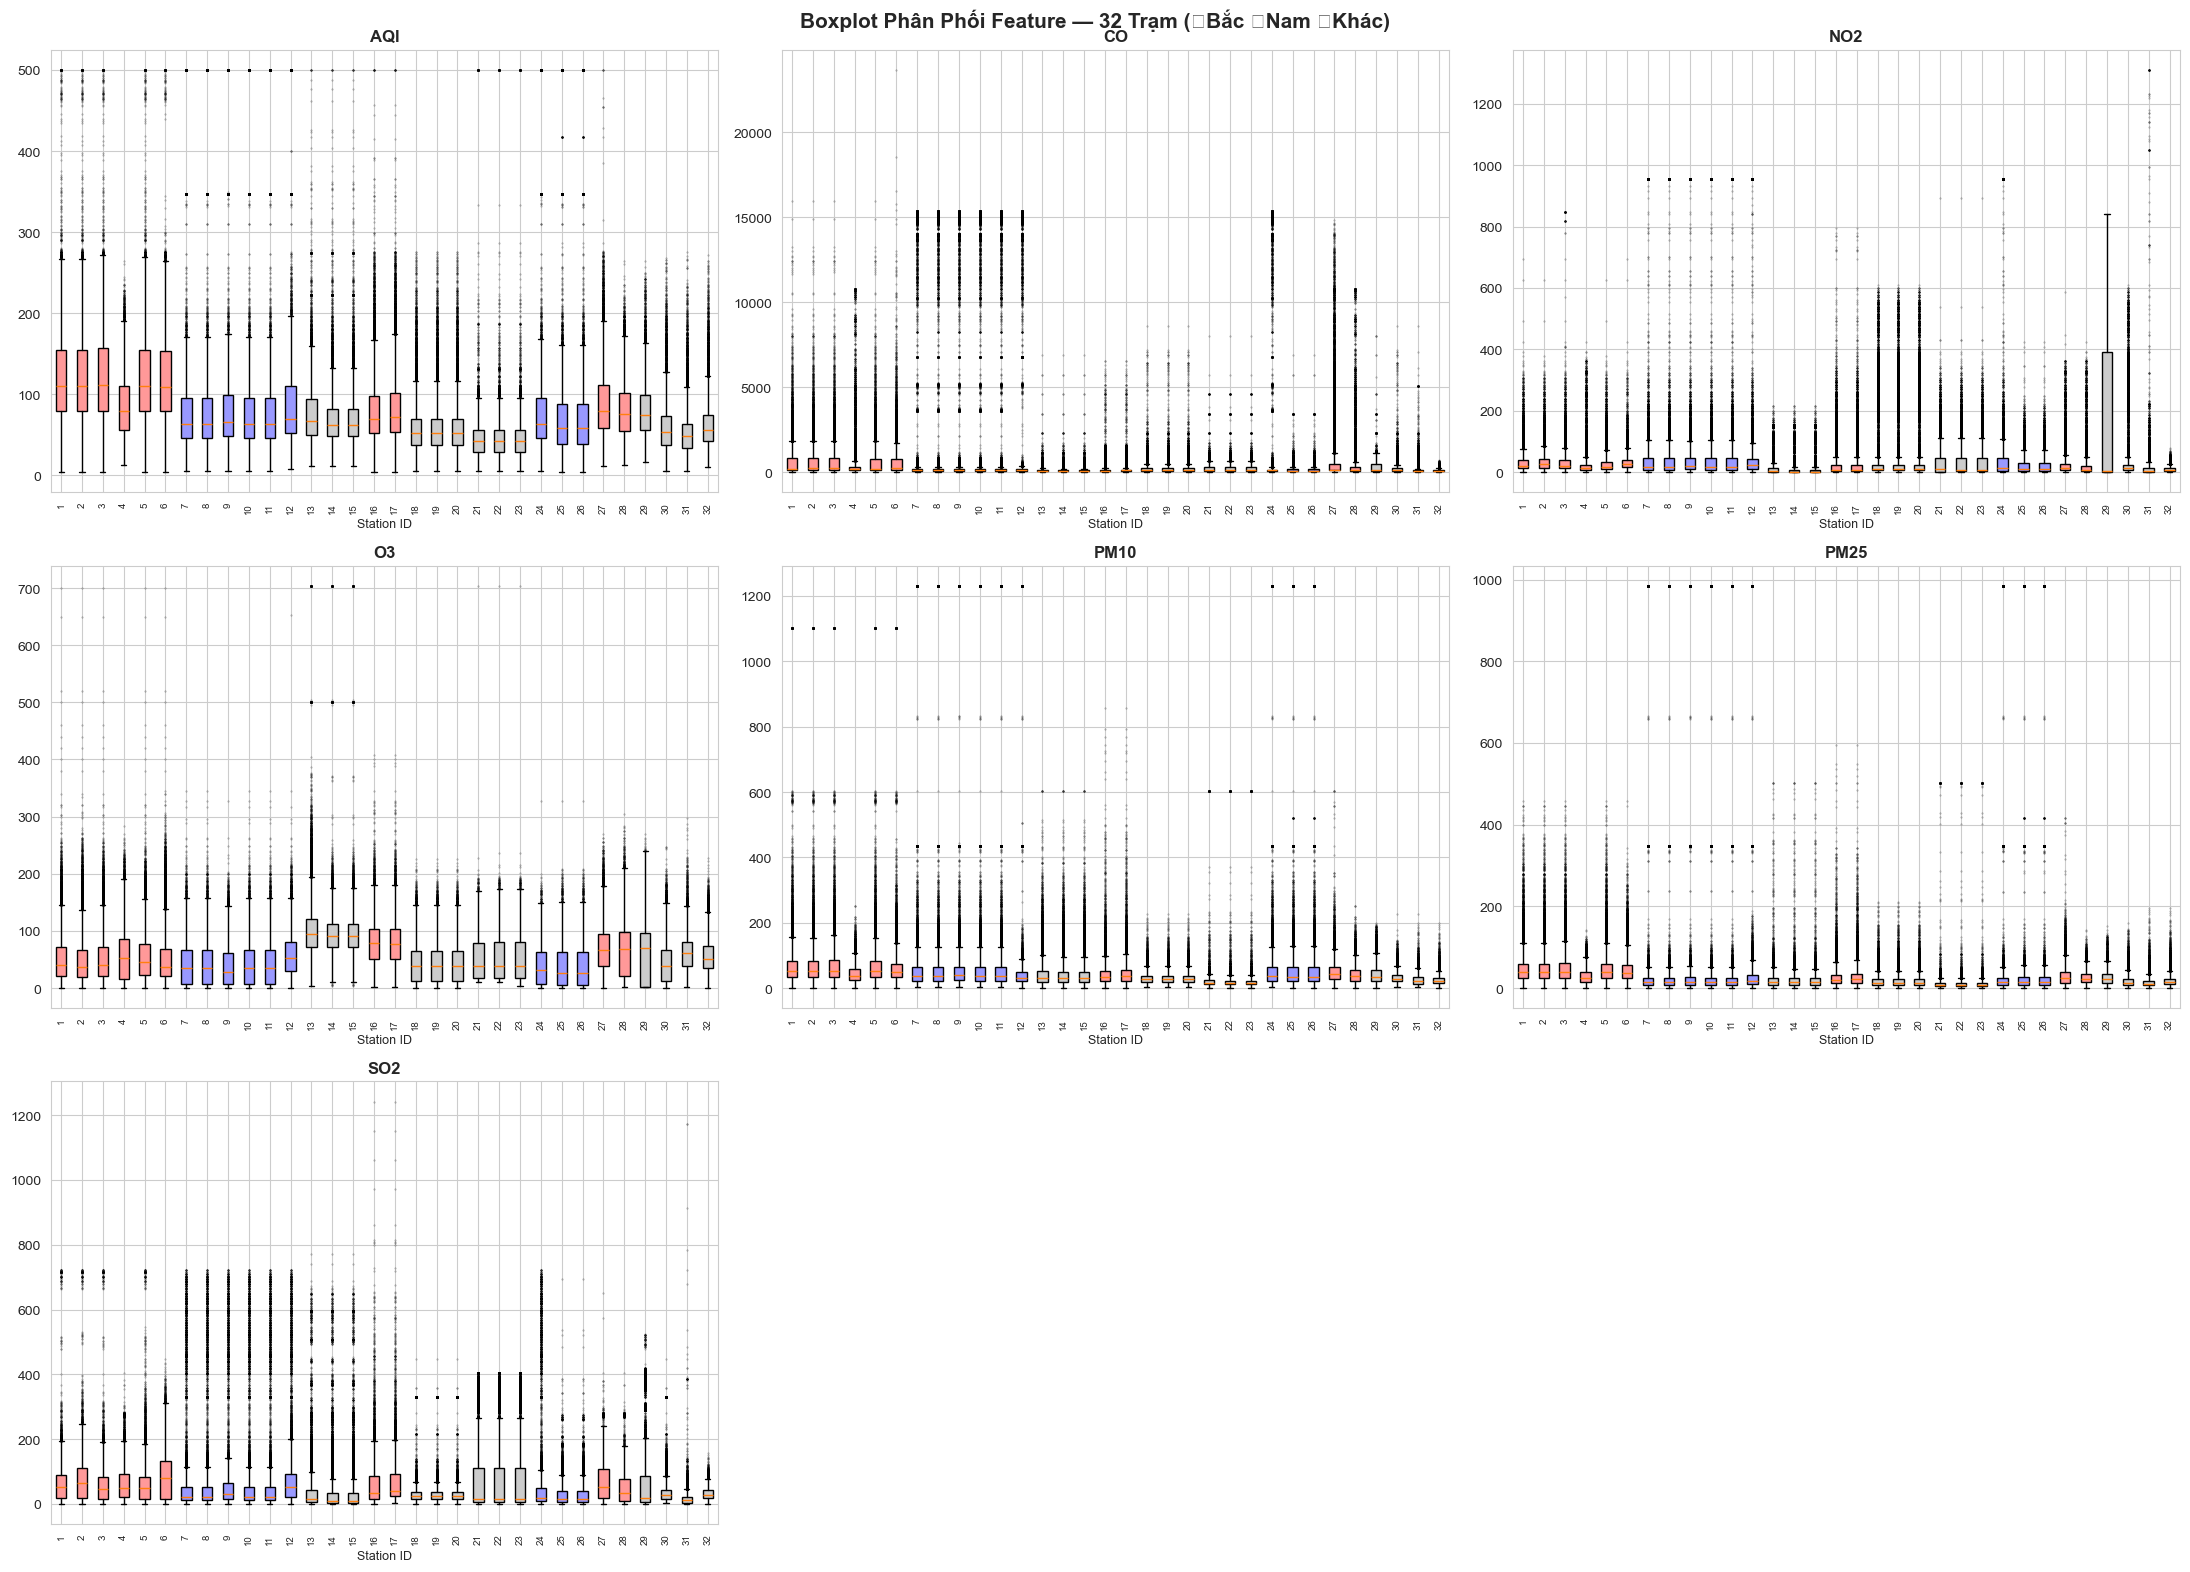

In [ ]:
# === BOXPLOT ALL FEATURES ===

fig, axes = plt.subplots(3, 3, figsize=(22, 16))
axes = axes.flatten()

for i, feat in enumerate(AIR_FEATURES):
    if i >= len(axes):
        break
    ax = axes[i]
    
    data_to_plot = []
    labels = []
    for sid in range(1, 33):
        if sid in all_air and feat in all_air[sid].columns:
            vals = all_air[sid][feat].dropna()
            if len(vals) > 0:
                data_to_plot.append(vals.values)
                labels.append(str(sid))
    
    bp = ax.boxplot(data_to_plot, labels=labels, showfliers=True,
                     flierprops=dict(marker='.', markersize=1, alpha=0.3),
                     patch_artist=True)
    
    # Color by region
    for j, patch in enumerate(bp['boxes']):
        sid_val = int(labels[j])
        if sid_val in [1,2,3,4,5,6,16,17,27,28]:
            patch.set_facecolor('#ff9999')  # North
        elif sid_val in [7,8,9,10,11,12,24,25,26]:
            patch.set_facecolor('#9999ff')  # South
        else:
            patch.set_facecolor('#cccccc')  # Other
    
    ax.set_title(feat.upper(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Station ID', fontsize=9)
    ax.tick_params(axis='x', rotation=90, labelsize=7)

# Hide unused
for j in range(len(AIR_FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplot Phân Phối Feature — 32 Trạm (🔴Bắc 🔵Nam ⚪Khác)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. 🌐 Tương Quan Chéo PM2.5 Giữa Các Trạm (Inter-Station Correlation)
Ma trận tương quan PM2.5 giữa các cặp trạm. Các trạm cùng cụm nên có tương quan cao (>0.5). Nếu tương quan thấp → trạm đó "sống riêng" không liên đới.


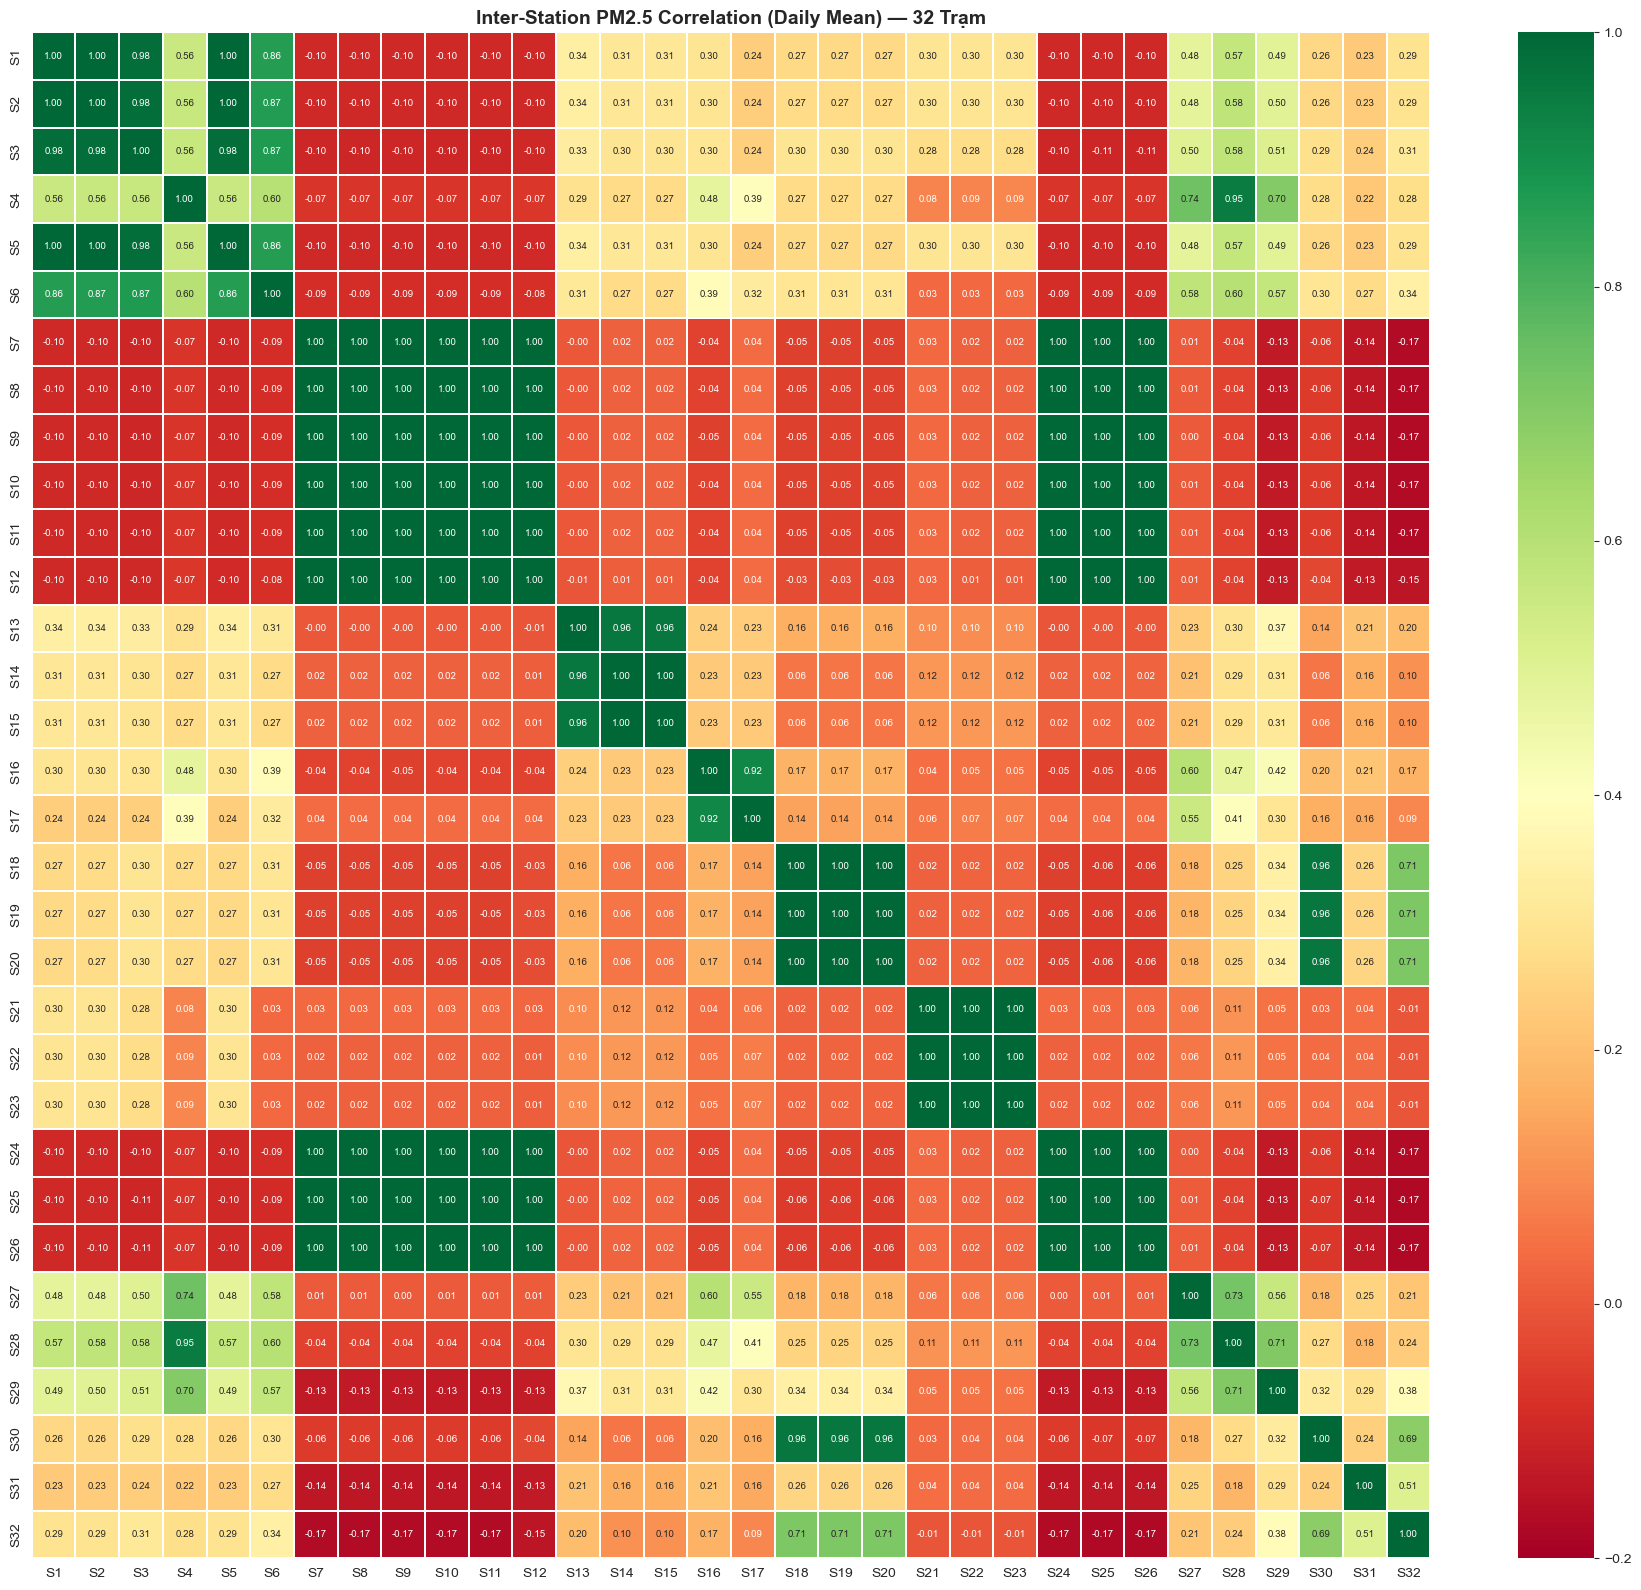


=== CỤM BẮC BỘ - Tương quan trung bình ===
  Avg correlation trong cụm Bắc Bộ: 0.595

=== CỤM NAM BỘ - Tương quan trung bình ===
  Avg correlation trong cụm Nam Bộ: 0.999


In [ ]:
# === INTER-STATION PM2.5 CORRELATION ===

# Merge PM2.5 from all stations into one DataFrame
pm25_all = pd.DataFrame()
for sid in range(1, 33):
    if sid in all_air and 'pm25' in all_air[sid].columns:
        pm25_all[f'S{sid}'] = all_air[sid]['pm25']

# Resample to daily mean for cleaner correlation
pm25_daily = pm25_all.resample('D').mean()

corr_matrix = pm25_daily.corr()

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-0.2, vmax=1, ax=ax, linewidths=0.2, annot_kws={'size': 7})
ax.set_title('Inter-Station PM2.5 Correlation (Daily Mean) — 32 Trạm', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Highlight cluster coherence
print("\n=== CỤM BẮC BỘ - Tương quan trung bình ===")
north_cols = [f'S{s}' for s in [1,2,3,4,5,6,16,17,27,28] if f'S{s}' in corr_matrix.columns]
north_corr = corr_matrix.loc[north_cols, north_cols]
mask_n = np.triu(np.ones_like(north_corr, dtype=bool), k=1)
avg_north = north_corr.where(~np.eye(len(north_corr), dtype=bool)).stack().mean()
print(f"  Avg correlation trong cụm Bắc Bộ: {avg_north:.3f}")

print("\n=== CỤM NAM BỘ - Tương quan trung bình ===")
south_cols = [f'S{s}' for s in [7,8,9,10,11,12,24,25,26] if f'S{s}' in corr_matrix.columns]
south_corr = corr_matrix.loc[south_cols, south_cols]
avg_south = south_corr.where(~np.eye(len(south_corr), dtype=bool)).stack().mean()
print(f"  Avg correlation trong cụm Nam Bộ: {avg_south:.3f}")


## 11. 📋 Bảng Tổng Hợp Đánh Giá Cuối Cùng
Bảng dưới đây tích hợp toàn bộ chỉ số đánh giá cho mỗi trạm, giúp bạn đưa ra quyết định chốt hạ lựa chọn Station.


In [ ]:
# === FINAL SUMMARY TABLE ===

final_summary = []
for sid in range(1, 33):
    row = {'Station ID': sid}
    
    # Province/District
    if sid in info['station'].values:
        row['Province'] = info.loc[info['station']==sid, 'province'].values[0]
        row['District'] = info.loc[info['station']==sid, 'district'].values[0]
    
    # Missing
    if sid in all_air:
        row['Air Missing (%)'] = round(all_air[sid].isna().mean().mean() * 100, 1)
        row['Total Hours'] = len(all_air[sid])
        
        # PM2.5 stats
        pm = all_air[sid]['pm25'].dropna()
        row['PM2.5 Mean'] = round(pm.mean(), 1) if len(pm) > 0 else None
        row['PM2.5 Max'] = round(pm.max(), 1) if len(pm) > 0 else None
        row['PM2.5 Std'] = round(pm.std(), 1) if len(pm) > 0 else None
        
    # Frozen events
    if sid in frozen_df.index:
        row['Frozen Events (PM2.5)'] = int(frozen_df.loc[sid, 'pm25'])
    
    # OPC errors
    opc_row = opc_df.loc[sid] if sid in opc_df.index else None
    if opc_row is not None:
        row['OPC Error (%)'] = opc_row['PM2.5 > PM10 (%)']
    
    # Cluster assignment
    if sid in [1,2,3,4,5,6,16,17,27,28]:
        row['Proposed Cluster'] = '🔴 Bắc Bộ'
    elif sid in [7,8,9,10,11,12,24,25,26]:
        row['Proposed Cluster'] = '🔵 Nam Bộ'
    else:
        row['Proposed Cluster'] = '⚪ Chưa chọn'
    
    final_summary.append(row)

final_df = pd.DataFrame(final_summary)
display(final_df.style.background_gradient(
    subset=['Air Missing (%)', 'PM2.5 Mean', 'Frozen Events (PM2.5)', 'OPC Error (%)'], 
    cmap='YlOrRd'
).format('{:.1f}', subset=['Air Missing (%)', 'PM2.5 Mean', 'PM2.5 Max', 'PM2.5 Std', 'OPC Error (%)'], na_rep='-'))

print("\n✅ Trạm ĐƯỢC CHỌN (19 trạm):", [1,2,3,4,5,6,7,8,9,10,11,12,16,17,24,25,26,27,28])
print("❌ Trạm BỊ LOẠI (13 trạm):", [13,14,15,18,19,20,21,22,23,29,30,31,32])


,Station ID,Province,District,Air Missing (%),Total Hours,PM2.5 Mean,PM2.5 Max,PM2.5 Std,Frozen Events (PM2.5),OPC Error (%),Proposed Cluster
0,1,Ha Noi,Cau Giay,0.0,25597,49.7,457.0,40.1,0,0.3,🔴 Bắc Bộ
1,2,Ha Noi,Thanh Xuan,0.0,25597,49.7,457.0,40.2,0,0.3,🔴 Bắc Bộ
2,3,Ha Noi,Tay Ho,0.0,25597,51.0,457.0,41.8,0,0.2,🔴 Bắc Bộ
3,4,Ha Noi,Yen Lang,0.0,25597,28.5,141.0,18.6,1,1.3,🔴 Bắc Bộ
4,5,Ha Noi,Gia Lam,0.0,25597,49.6,457.0,40.2,0,0.3,🔴 Bắc Bộ
5,6,Ha Noi,Ba Vi,0.0,25597,46.6,457.0,34.0,0,0.3,🔴 Bắc Bộ
6,7,TP.HCM,Quan 1,0.0,25597,83.4,985.0,243.2,16,0.1,🔵 Nam Bộ
7,8,TP.HCM,Quan 3,0.0,25597,83.4,985.0,243.2,16,0.1,🔵 Nam Bộ
8,9,TP.HCM,Quan Binh Thanh,0.0,25597,84.2,985.0,243.0,16,0.1,🔵 Nam Bộ
9,10,TP.HCM,Quan 10,0.0,25597,83.4,985.0,243.2,16,0.1,🔵 Nam Bộ



✅ Trạm ĐƯỢC CHỌN (19 trạm): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 16, 17, 24, 25, 26, 27, 28]
❌ Trạm BỊ LOẠI (13 trạm): [13, 14, 15, 18, 19, 20, 21, 22, 23, 29, 30, 31, 32]
